# NASDAQ 100 – Trendbasierte Frühindikatoren für ein Ampelsystem

### Eine Hypothesenanalyse auf Basis gleitender Durchschnitte

Diese Analyse untersucht sechs Hypothesen zur Aussagekraft gleitender
Durchschnitte (Simple Moving Averages, SMA) und verwandter technischer
Kennzahlen für den NASDAQ 100. Ziel ist die Identifikation robuster,
statistisch abgesicherter Frühindikatoren als Bausteine für ein
indikatorbasiertes Ampelsystem, das die aktuelle Marktphase hinsichtlich
ihres Rendite- und Risikoprofils einordnet.

Jede Hypothese wird in vier Schritten behandelt: Vorstellung und
Motivation, statistische Analyse mit grafischer Auswertung für **jede**
geprüfte Parametrisierung (auch wenn im Einzelfall keine statistische
Signifikanz vorliegt), Interpretation der Ergebnisse sowie eine Einschätzung der praktischen
Relevanz für Börseninvestoren und für das Ampelsystem. Sämtliche
Ergebnistabellen werden zusätzlich als CSV- und Excel-Dateien
bereitgestellt.


**Aufbau:**

1. Datenbezug und Aufbereitung
2. Datenbereinigung und Plausibilisierung
3. Methodik und Hypothesenübersicht
4. Hypothesenanalyse
5. Einordnung und Handlungsempfehlungen
6. Export der Ergebnisse
7. Zusammenfassung


## 1. Datenbezug und Aufbereitung

Grundlage der Analyse sind historische Tageskursdaten des NASDAQ 100. Dieser
Abschnitt beschreibt den Datenbezug sowie die verwendeten Software-Werkzeuge.


### 1.1 Verwendete Bibliotheken

- **pandas** – Datenstrukturen und -verarbeitung (tabellarische Zeitreihen).
- **numpy** – numerische Berechnungen.
- **scipy.stats** – statistische Signifikanztests (Abschnitt 3).
- **matplotlib** – grafische Auswertung.
- **yfinance** – Bezug historischer Börsendaten von Yahoo Finance.
- **pathlib.Path** – plattformunabhängige Dateipfadverwaltung.


In [1]:
# Numerik, Tabellenverarbeitung und Pfadhandling
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime
from itertools import combinations

# Statistische Tests (t-Test, Mann-Whitney-U) für den Gruppenvergleich in Abschnitt 3
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Kursdatenbezug über die inoffizielle Yahoo-Finance-Schnittstelle
import yfinance as yf

# Einheitliche Farbpalette für sämtliche Diagramme des Notebooks:
# COLOR_A/COLOR_B für neutrale Gruppenvergleiche, COLOR_GOOD/COLOR_WARN/COLOR_BAD
# für die Ampelfarben (Grün/Gelb/Rot) in den Abschnitten 6 und 7.
COLOR_PRICE = "#0b0b0b"
COLOR_A     = "#2a78d6"
COLOR_B     = "#eb6834"
COLOR_GOOD  = "#0ca30c"
COLOR_WARN  = "#e0a72c"
COLOR_BAD   = "#d03b3b"
COLOR_GRID  = "#e1e0d9"
COLOR_MUTED = "#898781"

# Globaler, dezenter Plot-Stil (schmale Gitterlinien, gedeckte Achsenfarben)
plt.rcParams.update({
    "figure.figsize": (11, 4.5),
    "axes.grid": True,
    "grid.color": COLOR_GRID,
    "grid.linewidth": 0.8,
    "axes.edgecolor": COLOR_MUTED,
    "axes.labelcolor": "#0b0b0b",
    "text.color": "#0b0b0b",
    "xtick.color": COLOR_MUTED,
    "ytick.color": COLOR_MUTED,
    "font.size": 10,
})

# Tabellenausgaben durchgehend mit vier Nachkommastellen und Tausendertrennzeichen
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
print("Bibliotheken geladen.")


Bibliotheken geladen.


### 1.2 Konfiguration

Die Analyse deckt den Zeitraum ab dem 01.01.2007 ab – dieser Zeitraum
schließt die globale Finanzkrise 2008 als Stresstest mit ein. Gleitende
Durchschnitte werden auf drei Zeitbasen berechnet: **Tages-, Wochen- und
Monatsbasis**. Die untersuchten Prognosehorizonte betragen 30, 60 und 90
Handelstage (entspricht etwa 6 Wochen, 3 Monaten und 4,5 Monaten).


In [2]:
# Zu untersuchender Index und sein Yahoo-Finance-Ticker
TICKER = "^NDX"
INDEX_NAME = "NASDAQ 100"

# Rohdaten werden ab 1900 geladen, damit auch frühe Handelstage für die
# Datenqualitätsprüfung zur Verfügung stehen; die eigentliche Analyse
# beschränkt sich anschliessend auf den Zeitraum ab 2007.
START_DATE_DOWNLOAD = "1900-01-01"
START_DATE_ANALYSE  = "2007-01-01"

# Fensterlängen der gleitenden Durchschnitte je Zeitbasis (Tage/Wochen/Monate)
SMA_WINDOWS_DAILY   = [20, 100, 200]
SMA_WINDOWS_WEEKLY  = [20, 100, 200]
SMA_WINDOWS_MONTHLY = [20, 50, 75]

# Prognosehorizonte in Handelstagen für die Zielgrößen (Vorwärtsrendite/-drawdown)
HORIZONS = [30, 60, 90]

# Zielordner für den Export der Ergebnistabellen (Abschnitt 8)
EXPORT_DIR = Path("Hypothesenanalysen")
EXPORT_DIR.mkdir(exist_ok=True)

print(f"Untersuchter Index: {INDEX_NAME} ({TICKER})")
print(f"Analysezeitraum ab: {START_DATE_ANALYSE}")
print(f"Ergebnisordner: {EXPORT_DIR.resolve()}")


Untersuchter Index: NASDAQ 100 (^NDX)
Analysezeitraum ab: 2007-01-01
Ergebnisordner: C:\Users\ramos\OneDrive\Privat\Data Science Institute\Abschlussprojekt - final\Gleitender Durchschnitt\Hypothesenanalysen


### 1.3 Kursdatenbezug

Bezogen werden **OHLCV-Daten** (Open/High/Low/Close/Volume) für jeden
Handelstag über die Programmierschnittstelle von Yahoo Finance. Das
verwendete Kürzel für den NASDAQ 100 lautet `^NDX`.


In [3]:
def lade_index_daten(ticker: str, start: str) -> pd.DataFrame:
    '''Lädt Tages-OHLCV-Daten von Yahoo Finance.'''
    raw = yf.download(ticker, start=start, auto_adjust=False, actions=False, progress=False)

    if raw.empty:
        raise ValueError(f"Keine Daten für \'{ticker}\' erhalten - Internetverbindung prüfen.")

    # yfinance liefert bei Einzeltickern gelegentlich einen MultiIndex in den
    # Spalten (Ticker-Ebene zusätzlich zur Feldebene) - wird hier auf eine
    # einfache Spaltenebene reduziert.
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = raw.columns.get_level_values(0)
    raw.columns.name = None
    raw.index.name = "Date"
    return raw


abrufdatum = datetime.now().strftime("%Y-%m-%d %H:%M")
df_raw = lade_index_daten(TICKER, START_DATE_DOWNLOAD)

print(f"Abgerufen am: {abrufdatum}")
print(f"{INDEX_NAME}: {len(df_raw):,} Zeilen, Zeitraum {df_raw.index.min().date()} bis {df_raw.index.max().date()}")
df_raw.head()


Abgerufen am: 2026-08-19 17:58
NASDAQ 100: 10,297 Zeilen, Zeitraum 1985-10-01 bis 2026-08-19


,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
1985-10-01,112.1400,112.1400,112.1600,110.5650,110.6200,153160000
1985-10-02,110.8250,110.8250,112.5400,110.7800,112.1400,164640000
1985-10-03,110.8700,110.8700,111.1850,110.1200,110.8400,147300000
1985-10-04,110.0750,110.0750,110.8700,109.8550,110.8700,147900000
1985-10-07,108.2000,108.2000,110.1350,108.1750,110.0750,128640000


## 2. Datenbereinigung und Plausibilisierung

Vor der eigentlichen Analyse werden die Rohdaten systematisch auf
typische Qualitätsprobleme geprüft: doppelte Datumseinträge, fehlende
Werte, ungewöhnliche Zeitlücken zwischen Handelstagen sowie unplausible
oder extreme Kurswerte.


### 2.1 Datenqualitätsprüfung


In [4]:
def datenqualität_report(df: pd.DataFrame) -> dict:
    # Kalendertage zwischen aufeinanderfolgenden Handelstagen - größere
    # Lücken als das übliche Wochenend-/Feiertagsmuster deuten auf fehlende
    # Handelstage hin.
    gap_days = df.index.to_series().diff().dt.days
    daily_return = df["Close"].pct_change()
    return {
        "Anzahl Zeilen": len(df),
        "Duplizierte Datums-Indizes": int(df.index.duplicated().sum()),
        "Fehlende Werte in Close": int(df["Close"].isna().sum()),
        "Handelstage-Lücken > 4 Kalendertage": int((gap_days > 4).sum()),
        "Größte Lücke (Kalendertage)": float(gap_days.max()) if len(gap_days.dropna()) else np.nan,
        "Close <= 0": int((df["Close"] <= 0).sum()),
        "Tagesrenditen > 20% (absolut)": int((daily_return.abs() > 0.20).sum()),
    }


dq_report = datenqualität_report(df_raw)
print(f"--- Datenqualitätsbericht: {INDEX_NAME} (Rohdaten) ---")
for k, v in dq_report.items():
    print(f"{k:.<45s} {v}")


--- Datenqualitätsbericht: NASDAQ 100 (Rohdaten) ---
Anzahl Zeilen................................ 10297
Duplizierte Datums-Indizes................... 0
Fehlende Werte in Close...................... 0
Handelstage-Lücken > 4 Kalendertage.......... 3
Größte Lücke (Kalendertage).................. 7.0
Close <= 0................................... 0
Tagesrenditen > 20% (absolut)................ 0


Die identifizierten Zeitlücken (3 Lücken über 4 Kalendertage, die größte davon 7 Kalendertage) entsprechen regulären Börsenschließungen (Wochenenden, US-Feiertage) und stellen keine Datenfehler dar. Der NASDAQ 100 weist in der vorliegenden Historie keinen einzigen Handelstag mit einer absoluten Tagesrendite über 20 % auf – selbst die stärksten Einbrüche der Finanzkrise 2008 und der Corona-Pandemie 2020 blieben unterhalb dieser Schwelle. Die Datenqualität gibt damit keinen Anlass für zusätzliche Bereinigungsschritte.

### 2.2 Bereinigungsschritte

Angewendet werden drei Bereinigungsschritte: Entfernen doppelter
Datumszeilen, Verwerfen eines gegebenenfalls unvollständigen aktuellen
Handelstags (fehlender finaler Schlusskurs aufgrund der Datenpipeline von
Yahoo Finance) sowie zeitbasierte Interpolation vereinzelter fehlender
Schlusskurse innerhalb der Historie (begrenzt auf maximal zwei
aufeinanderfolgende Tage, um längere Datenlücken nicht zu verschleiern).


In [5]:
def bereinige_daten(df: pd.DataFrame) -> pd.DataFrame:
    df_clean = df.copy()

    # Doppelte Datums-Indizes können durch Datenfehler beim Anbieter entstehen;
    # der erste Eintrag je Datum wird behalten.
    n_dupes = df_clean.index.duplicated().sum()
    df_clean = df_clean[~df_clean.index.duplicated(keep="first")].sort_index()

    # Unvollständige Handelstage am aktuellen Rand (z. B. der laufende, noch
    # nicht abgeschlossene Handelstag) werden verworfen, um verzerrte
    # Kennzahlen am Ende der Zeitreihe zu vermeiden.
    letzter_valider_close = df_clean["Close"].last_valid_index()
    n_unvollständig = int((df_clean.index > letzter_valider_close).sum()) if letzter_valider_close is not None else 0
    if n_unvollständig > 0:
        print(f"Unvollständige(r) Handelstag(e) am aktuellen Rand verworfen: {n_unvollständig}")
        df_clean = df_clean.loc[:letzter_valider_close]

    # Kurzfristige Datenlücken (max. zwei aufeinanderfolgende Handelstage)
    # werden zeitbasiert interpoliert statt verworfen, damit die Zeitreihe
    # für rollierende Berechnungen (SMA) durchgängig bleibt.
    n_na_before = df_clean["Close"].isna().sum()
    df_clean["Close"] = df_clean["Close"].interpolate(method="time", limit=2)
    n_na_after = df_clean["Close"].isna().sum()

    print(f"Duplikate entfernt: {n_dupes}")
    print(f"Fehlende Close-Werte: {n_na_before} -> {n_na_after} (nach Interpolation, max. 2 Tage am Stück)")
    return df_clean


df_clean = bereinige_daten(df_raw)


Duplikate entfernt: 0
Fehlende Close-Werte: 0 -> 0 (nach Interpolation, max. 2 Tage am Stück)


### 2.3 Abgrenzung des Analysezeitraums

Die weitere Analyse beschränkt sich auf den Zeitraum ab dem 01.01.2007.


In [6]:
# Ab hier wird ausschliesslich mit dem auf den Analysezeitraum (ab 2007)
# beschränkten Datensatz gearbeitet.
df = df_clean.loc[START_DATE_ANALYSE:].copy()
print(f"{INDEX_NAME}: {len(df):,} Zeilen im Analysezeitraum {df.index.min().date()} bis {df.index.max().date()}")
df[["Open", "High", "Low", "Close", "Volume"]].describe()


NASDAQ 100: 4,935 Zeilen im Analysezeitraum 2007-01-03 bis 2026-08-19


,Open,High,Low,Close,Volume
count,"4,935.0000","4,935.0000","4,935.0000","4,935.0000","4,935.0000"
mean,"8,066.8792","8,123.2329","8,005.7406","8,068.7040","3,340,636,332.7777"
std,"7,051.9364","7,099.4631","6,998.1427","7,052.7842","2,274,646,142.4342"
min,"1,058.8500","1,085.5699","1,018.8600","1,036.5100","221,430,000.0000"
25%,"2,376.7250","2,388.4349","2,360.4500","2,376.2550","1,871,680,000.0000"
50%,"4,824.2700","4,840.8101","4,804.2402","4,819.8999","2,206,400,000.0000"
75%,"12,587.3853","12,707.9453","12,462.7402","12,603.3198","4,473,860,000.0000"
max,"30,730.1094","30,762.1992","30,441.8008","30,660.5996","18,286,150,000.0000"


### 2.4 Gleitende Durchschnitte (SMA)

Ein gleitender Durchschnitt (Simple Moving Average, SMA) glättet eine
Kurszeitreihe, indem für jeden Zeitpunkt der Durchschnitt der letzten *n*
Kurswerte gebildet wird. Damit lassen sich kurzfristige Schwankungen von der
zugrundeliegenden Trendrichtung trennen. Berechnet werden SMA auf **Tages-,
Wochen- und Monatsbasis**, jeweils mit unterschiedlichen Fensterlängen: Ein
SMA20 auf Tagesbasis erfasst rund einen Monat Historie, ein SMA20 auf
Monatsbasis dagegen rund 20 Monate.


In [7]:
# min_periods=w erzwingt, dass erst ab dem vollen Fenster ein SMA-Wert
# ausgewiesen wird (keine verkürzten, irreführenden Anfangswerte).
for w in SMA_WINDOWS_DAILY:
    df[f"SMA{w}_d"] = df["Close"].rolling(window=w, min_periods=w).mean()

print("Tagesbasis-SMA berechnet:", [f"SMA{w}_d" for w in SMA_WINDOWS_DAILY])
df[["Close"] + [f"SMA{w}_d" for w in SMA_WINDOWS_DAILY]].tail()


Tagesbasis-SMA berechnet: ['SMA20_d', 'SMA100_d', 'SMA200_d']


,Close,SMA20_d,SMA100_d,SMA200_d
Date,,,,
2026-08-13,"30,084.5000","28,953.1731","28,066.8032","26,661.5905"
2026-08-14,"30,046.1406","28,976.1657","28,123.0137","26,687.4261"
2026-08-17,"29,995.3809","29,000.8048","28,179.4147","26,711.9160"
2026-08-18,"29,490.9609","29,024.0644","28,235.3428","26,732.5800"
2026-08-19,"29,499.0625","29,069.3845","28,288.4475","26,750.9675"


In [8]:
# Wochenschlusskurse (freitags) als Grundlage für die Wochenbasis-SMA
wochenschluss = df["Close"].resample("W-FRI").last().dropna()

for w in SMA_WINDOWS_WEEKLY:
    wochen_sma = wochenschluss.rolling(window=w, min_periods=w).mean().rename(f"SMA{w}_w")
    # merge_asof mit direction="backward" ordnet jedem Handelstag den zuletzt
    # bekannten Wochen-SMA-Wert zu (kein Vorgriff auf künftige Wochenabschlüsse).
    mapped = pd.merge_asof(
        df.reset_index()[["Date"]], wochen_sma.reset_index(), on="Date", direction="backward",
    )
    df[f"SMA{w}_w"] = mapped[f"SMA{w}_w"].values

print("Wochenbasis-SMA berechnet:", [f"SMA{w}_w" for w in SMA_WINDOWS_WEEKLY])
df[["Close"] + [f"SMA{w}_w" for w in SMA_WINDOWS_WEEKLY]].tail()


Wochenbasis-SMA berechnet: ['SMA20_w', 'SMA100_w', 'SMA200_w']


,Close,SMA20_w,SMA100_w,SMA200_w
Date,,,,
2026-08-13,"30,084.5000","28,198.9028","23,636.7101","19,521.2114"
2026-08-14,"30,046.1406","28,544.5714","23,742.0256","19,617.9818"
2026-08-17,"29,995.3809","28,544.5714","23,742.0256","19,617.9818"
2026-08-18,"29,490.9609","28,544.5714","23,742.0256","19,617.9818"
2026-08-19,"29,499.0625","28,544.5714","23,742.0256","19,617.9818"


In [9]:
# Monatsschlusskurse (letzter Handelstag im Monat) als Grundlage für die Monatsbasis-SMA
monatsschluss = df["Close"].resample("ME").last().dropna()

for w in SMA_WINDOWS_MONTHLY:
    monats_sma = monatsschluss.rolling(window=w, min_periods=w).mean().rename(f"SMA{w}_m")
    # Gleiches Mapping-Prinzip wie bei der Wochenbasis: jedem Handelstag wird
    # der zuletzt bekannte Monats-SMA-Wert zugeordnet.
    mapped = pd.merge_asof(
        df.reset_index()[["Date"]], monats_sma.reset_index(), on="Date", direction="backward",
    )
    df[f"SMA{w}_m"] = mapped[f"SMA{w}_m"].values

print("Monatsbasis-SMA berechnet:", [f"SMA{w}_m" for w in SMA_WINDOWS_MONTHLY])
df[["Close"] + [f"SMA{w}_m" for w in SMA_WINDOWS_MONTHLY]].tail()


Monatsbasis-SMA berechnet: ['SMA20_m', 'SMA50_m', 'SMA75_m']


,Close,SMA20_m,SMA50_m,SMA75_m
Date,,,,
2026-08-13,"30,084.5000","24,226.0559","18,973.3513","17,107.9228"
2026-08-14,"30,046.1406","24,226.0559","18,973.3513","17,107.9228"
2026-08-17,"29,995.3809","24,226.0559","18,973.3513","17,107.9228"
2026-08-18,"29,490.9609","24,226.0559","18,973.3513","17,107.9228"
2026-08-19,"29,499.0625","24,226.0559","18,973.3513","17,107.9228"


### 2.5 Zielgrößen

Für jeden Handelstag werden zwei Zielgrößen für die Prognosehorizonte
30, 60 und 90 Handelstage berechnet:

- **Forward Return** – die prozentuale Kursveränderung bis zum Ende des
  jeweiligen Horizonts (Renditekennzahl).
- **Forward Maximum Drawdown** – der größte zwischenzeitliche prozentuale
  Rückgang vom laufenden Höchststand innerhalb des Horizonts
  (Risikokennzahl).


In [10]:
def forward_return(close: pd.Series, horizon: int) -> pd.Series:
    # Prozentuale Kursveränderung vom aktuellen Tag bis horizon Handelstage später
    return close.shift(-horizon) / close - 1


def forward_max_drawdown(close: pd.Series, horizon: int) -> pd.Series:
    # Größter zwischenzeitlicher Rückgang vom laufenden Hoch innerhalb des
    # Fensters [i, i+horizon] - im Unterschied zu forward_return also nicht
    # nur der End-, sondern der ungünstigste Zwischenstand des Horizonts.
    values = close.values
    n = len(values)
    out = np.full(n, np.nan)
    for i in range(n - horizon):
        fenster = values[i : i + horizon + 1]
        laufendes_hoch = np.maximum.accumulate(fenster)
        out[i] = (fenster / laufendes_hoch - 1).min()
    return pd.Series(out, index=close.index)


for h in HORIZONS:
    df[f"fwd_return_{h}d"] = forward_return(df["Close"], h)
    df[f"fwd_mdd_{h}d"] = forward_max_drawdown(df["Close"], h)

print("Zielgrößen berechnet für Horizonte:", HORIZONS)
df.filter(like="fwd_").describe()


Zielgrößen berechnet für Horizonte:

 [30, 60, 90]


,fwd_return_30d,fwd_mdd_30d,fwd_return_60d,fwd_mdd_60d,fwd_return_90d,fwd_mdd_90d
count,"4,905.0000","4,905.0000","4,875.0000","4,875.0000","4,845.0000","4,845.0000"
mean,0.0195,-0.0609,0.0395,-0.0882,0.0593,-0.1086
std,0.0670,0.0474,0.0931,0.0634,0.1134,0.0731
min,-0.3370,-0.3370,-0.4546,-0.4588,-0.4379,-0.4723
25%,-0.0169,-0.0790,-0.0050,-0.1131,0.0091,-0.1283
50%,0.0258,-0.0460,0.0474,-0.0729,0.0702,-0.0857
75%,0.0598,-0.0273,0.0922,-0.0435,0.1232,-0.0597
max,0.2745,-0.0055,0.4379,-0.0155,0.5293,-0.0160


## 3. Methodik und Hypothesenübersicht

### 3.1 Statistisches Prüfverfahren

Jede Hypothese folgt demselben Grundmuster: Die Handelstage werden anhand
eines definierten Kriteriums in zwei Gruppen eingeteilt (z. B. "Kurs über
SMA200" versus "Kurs unter SMA200"), anschließend wird verglichen, wie sich
die beiden Zielgrößen (Forward Return, Forward Maximum Drawdown) in den
beiden Gruppen im Mittel unterscheiden.

Zur Beurteilung, ob ein beobachteter Unterschied statistisch belastbar ist
oder zufällig zustande gekommen sein könnte, werden zwei unabhängige Tests
herangezogen:

- **Welch-t-Test** – vergleicht die Mittelwerte zweier Verteilungen unter
  der Annahme unterschiedlicher Varianzen.
- **Mann-Whitney-U-Test** – ein verteilungsfreies Verfahren, das die
  gesamte Rangordnung beider Stichproben vergleicht und dadurch weniger
  empfindlich gegenüber einzelnen Extremwerten ist.

Ein Unterschied wird in dieser Analyse als **statistisch signifikant**
gewertet, wenn **beide** Tests unabhängig voneinander ein
Signifikanzniveau von unter 5 % (p < 0,05) anzeigen. Zusätzlich gilt eine
**Mindeststichprobengröße von 10 Beobachtungen je Gruppe**; unterhalb
dieser Schwelle wird kein Testergebnis ausgewiesen.

**Einschränkung:** Handelstage sind zeitlich nicht unabhängig voneinander
(Autokorrelation), da zusammenhängende Markttrends aus vielen benachbarten,
ähnlich gerichteten Tagen bestehen. Die hier verwendeten Tests unterstellen
jedoch näherungsweise unabhängige Beobachtungen. Die berichteten
p-Werte sind daher als Anhaltspunkt und nicht als exakte
Wahrscheinlichkeitsaussage zu interpretieren.


In [11]:
def vergleiche_gruppen(gruppe_a: pd.Series, gruppe_b: pd.Series,
                        label_a: str = "Gruppe A", label_b: str = "Gruppe B") -> dict | None:
    a = gruppe_a.dropna()
    b = gruppe_b.dropna()

    # Mindeststichprobe je Gruppe, unterhalb derer ein Test nicht als
    # belastbar gilt - Vergleich wird in diesem Fall übersprungen (None).
    if len(a) < 10 or len(b) < 10:
        return None

    # Welch-t-Test (robust bei ungleicher Varianz) und Mann-Whitney-U-Test
    # (verteilungsfrei) parallel geprüft; als "signifikant" gilt nur ein
    # Ergebnis, das in beiden Tests unter 5 % liegt - reduziert das Risiko
    # eines durch Verteilungsannahmen verzerrten Befunds.
    t_stat, t_p = stats.ttest_ind(a, b, equal_var=False)
    u_stat, u_p = stats.mannwhitneyu(a, b, alternative="two-sided")

    return {
        "label_a": label_a, "n_a": len(a), "mean_a": a.mean(), "median_a": a.median(), "std_a": a.std(),
        "label_b": label_b, "n_b": len(b), "mean_b": b.mean(), "median_b": b.median(), "std_b": b.std(),
        "t_pvalue": t_p, "u_pvalue": u_p,
        "signifikant_5pct": bool(t_p < 0.05 and u_p < 0.05),
    }


def ergebnisse_zu_tabelle(ergebnisse: list[dict]) -> pd.DataFrame:
    return pd.DataFrame(ergebnisse)


print("Statistisches Prüfverfahren definiert.")


Statistisches Prüfverfahren definiert.


### 3.2 Untersuchte Hypothesen

| # | Hypothese | Kriterium |
|---|---|---|
| H1 | Kurs über/unter SMA | Notiert der Kurs über oder unter seinem gleitenden Durchschnitt? |
| H2 | SMA-Richtung | Steigt oder fällt der gleitende Durchschnitt selbst? |
| H3 | Cross-Over | Kreuzt ein kurzfristiger SMA einen langfristigen SMA (Golden/Death Cross)? |
| H4 | Divergenz | Läuft der kurzfristige Trend dem längerfristigen Trend entgegen? |
| H5 | Abstand vom Hoch | Wie weit notiert der Kurs unter seinem bisherigen Höchststand? |
| H6 | Momentum (RSI) | Ist eine Kursbewegung technisch überkauft oder überverkauft? |

H1 und H2 werden für alle drei Tagesbasis-Fenster (SMA20/100/200) geprüft,
H3 für sämtliche neun möglichen SMA-Paare über Tages-, Wochen- und
Monatsbasis, H4 für zwei Divergenzmuster auf unterschiedlichen Zeitebenen.
Für **jede** geprüfte Parametrisierung wird ein Ergebnis ausgewiesen und
grafisch dargestellt – auch dort, wo keine statistische Signifikanz
vorliegt, da auch ein nicht signifikanter Befund für die Bewertung der
Praxistauglichkeit eines Indikators relevant ist.


## 4. Hypothesenanalyse

Für jede Parametrisierung wird ein Balkendiagramm erstellt, das die
mittlere Vorwärtsrendite sowie den mittleren maximalen Rückgang je
Prognosehorizont für beide verglichenen Gruppen gegenüberstellt.


In [12]:
def plotte_gruppenvergleich(tabelle: pd.DataFrame, titel: str) -> None:
    # Zwei Teilplots nebeneinander: links Rendite-, rechts Risikovergleich,
    # jeweils als gruppierte Balken über die drei Prognosehorizonte.
    fig, achsen = plt.subplots(1, 2, figsize=(11, 4))
    for achse, ziel, beschriftung in zip(achsen, ["fwd_return", "fwd_mdd"],
                                          ["Ø Vorwärtsrendite", "Ø maximaler Rückgang (Drawdown)"]):
        teil = tabelle[tabelle["zielgröße"] == ziel]
        x = np.arange(len(teil))
        breite = 0.35
        achse.bar(x - breite / 2, teil["mean_a"] * 100, breite, label=teil["label_a"].iloc[0], color=COLOR_A)
        achse.bar(x + breite / 2, teil["mean_b"] * 100, breite, label=teil["label_b"].iloc[0], color=COLOR_B)
        achse.set_xticks(x)
        achse.set_xticklabels([f"{h}d" for h in teil["horizont_tage"]])
        achse.set_ylabel(f"{beschriftung} (%)")
        achse.axhline(0, color=COLOR_MUTED, linewidth=0.8)
        achse.legend(fontsize=8)
    fig.suptitle(titel)
    fig.tight_layout()
    plt.show()


print("Funktion zur grafischen Auswertung definiert.")


Funktion zur grafischen Auswertung definiert.


In [13]:
# Sammelt die Ergebnistabellen aller Hypothesen für die Robustheitsübersicht (4.7) und den Export (Abschnitt 8)
alle_ergebnisse: dict[str, pd.DataFrame] = {}


### 4.1 H1 – Kurs über oder unter SMA

**Hypothese:** Die Position des Kurses relativ zu seinem gleitenden
Durchschnitt liefert Information über die zu erwartende Rendite- und
Risikosituation der Folgeperiode. Geprüft wird dies für die drei
Tagesbasis-Fenster SMA20, SMA100 und SMA200.


In [14]:
def regime_gruppen(sma_fenster: int) -> tuple[pd.Series, pd.Series]:
    # Zustand "Kurs über/unter SMA" je Handelstag; Tage ohne gültigen SMA-Wert
    # (Anfang der Zeitreihe) werden in beiden Gruppen ausgeschlossen.
    sma = df[f"SMA{sma_fenster}_d"]
    valide = sma.notna()
    über = (df["Close"] > sma) & valide
    unter = (df["Close"] <= sma) & valide
    return über, unter


ergebnisse_h1 = []
for w in SMA_WINDOWS_DAILY:
    über, unter = regime_gruppen(w)
    for h in HORIZONS:
        for ziel in ["fwd_return", "fwd_mdd"]:
            res = vergleiche_gruppen(
                df.loc[über, f"{ziel}_{h}d"], df.loc[unter, f"{ziel}_{h}d"],
                label_a=f"Kurs > SMA{w}", label_b=f"Kurs < SMA{w}",
            )
            if res:
                res.update({"sma_fenster": w, "horizont_tage": h, "zielgröße": ziel})
                ergebnisse_h1.append(res)

tabelle_h1 = ergebnisse_zu_tabelle(ergebnisse_h1)
alle_ergebnisse["H1_Kurs_vs_SMA"] = tabelle_h1
spalten_anzeige = ["sma_fenster", "horizont_tage", "zielgröße", "label_a", "mean_a", "label_b", "mean_b",
                    "t_pvalue", "u_pvalue", "signifikant_5pct"]
spalten_anzeige_einfach = [c for c in spalten_anzeige if c != "sma_fenster"]
tabelle_h1[spalten_anzeige]


,sma_fenster,horizont_tage,zielgröße,label_a,mean_a,label_b,mean_b,t_pvalue,u_pvalue,signifikant_5pct
0,20,30,fwd_return,Kurs > SMA20,0.0167,Kurs < SMA20,0.0250,0.0002,0.0000,True
1,20,30,fwd_mdd,Kurs > SMA20,-0.0557,Kurs < SMA20,-0.0709,0.0000,0.0000,True
2,20,60,fwd_return,Kurs > SMA20,0.0345,Kurs < SMA20,0.0494,0.0000,0.0000,True
3,20,60,fwd_mdd,Kurs > SMA20,-0.0830,Kurs < SMA20,-0.0983,0.0000,0.0000,True
4,20,90,fwd_return,Kurs > SMA20,0.0538,Kurs < SMA20,0.0697,0.0000,0.0000,True
5,20,90,fwd_mdd,Kurs > SMA20,-0.1039,Kurs < SMA20,-0.1178,0.0000,0.0001,True
6,100,30,fwd_return,Kurs > SMA100,0.0165,Kurs < SMA100,0.0283,0.0000,0.0000,True
7,100,30,fwd_mdd,Kurs > SMA100,-0.0545,Kurs < SMA100,-0.0820,0.0000,0.0000,True
8,100,60,fwd_return,Kurs > SMA100,0.0351,Kurs < SMA100,0.0516,0.0000,0.0000,True
9,100,60,fwd_mdd,Kurs > SMA100,-0.0808,Kurs < SMA100,-0.1135,0.0000,0.0000,True


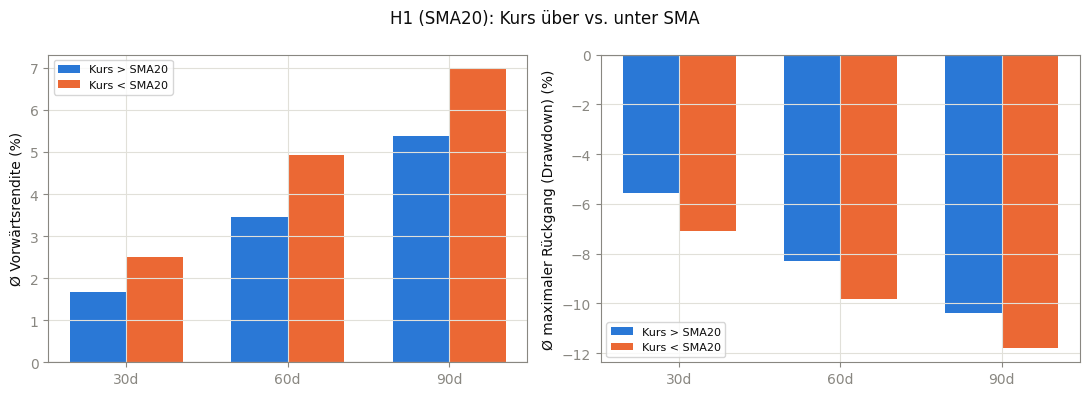

In [15]:
# Stellvertretend für das empfindlichste Fenster (SMA20) - SMA100/SMA200 folgen in den nächsten beiden Zellen
plotte_gruppenvergleich(tabelle_h1[tabelle_h1["sma_fenster"] == 20], "H1 (SMA20): Kurs über vs. unter SMA")


**Ergebnis SMA20:** Für beide Zielgrößen liegt in allen drei Horizonten statistische Signifikanz vor, allerdings in gegenläufiger Richtung: Der maximale Rückgang war bei einem Kurs über SMA20 durchgehend signifikant geringer (90 Tage: −10,4 % gegenüber −11,8 %). Die Rendite verhielt sich entgegen der intuitiven Erwartung – sie war bei einem Kurs *unter* SMA20 signifikant höher (90 Tage: 6,9 % gegenüber 5,4 %). Dieses Muster entspricht einem Mean-Reversion-Effekt: kurzfristige Schwächephasen erholten sich historisch überdurchschnittlich häufig.

**Praxisrelevanz für Börseninvestoren:** Ein Investor, der SMA20 als kurzfristiges Signal heranzieht, sollte nicht davon ausgehen, dass ein Kurs über SMA20 automatisch die höhere erwartete Rendite bietet – historisch war eher das Gegenteil der Fall. Als kurzfristiger Risikofilter ist SMA20 hingegen brauchbar: Phasen unterhalb des SMA20 gingen mit signifikant größeren Rückgängen einher.

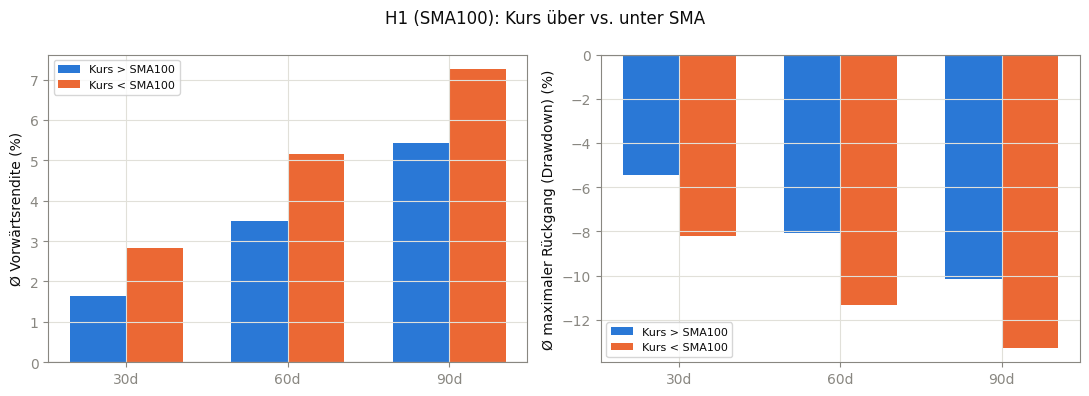

In [16]:
# Gleiche Auswertung wie oben, hier für das mittlere Fenster SMA100
plotte_gruppenvergleich(tabelle_h1[tabelle_h1["sma_fenster"] == 100], "H1 (SMA100): Kurs über vs. unter SMA")


**Ergebnis SMA100:** Sowohl der Risiko- als auch der Renditeunterschied bleiben über alle drei Horizonte durchgängig signifikant – der bei SMA20 beobachtete Mean-Reversion-Effekt verwässert sich bei diesem mittleren Fenster nicht: Auch bei 60 und 90 Tagen liegt die Rendite bei einem Kurs unter SMA100 signifikant höher (90 Tage: 7,2 % gegenüber 5,4 %), während der maximale Rückgang bei einem Kurs über SMA100 durchgehend signifikant kleiner ausfällt (90 Tage: −10,2 % gegenüber −13,3 %).

**Praxisrelevanz für Börseninvestoren:** SMA100 liefert im vorliegenden Datensatz ein durchgängig belastbares, wenn auch gegenläufiges Signal: Sowohl als Risikofilter als auch – entgegen der intuitiven Erwartung – als kurzfristiges Contrarian-Renditesignal ist es über sämtliche geprüften Horizonte statistisch abgesichert.

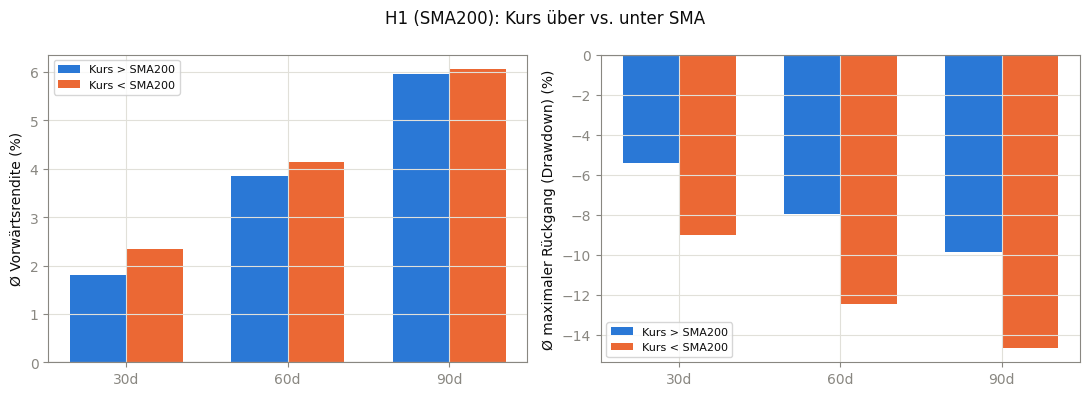

In [17]:
# Gleiche Auswertung wie oben, hier für das langfristige Fenster SMA200 -
# im Notebook als robusteste Basis identifiziert (siehe Ergebnis-Text unten)
plotte_gruppenvergleich(tabelle_h1[tabelle_h1["sma_fenster"] == 200], "H1 (SMA200): Kurs über vs. unter SMA")


**Ergebnis SMA200:** Der Risikounterschied bleibt über alle Horizonte klar signifikant (90 Tage: −9,9 % über dem SMA200 gegenüber −14,7 % darunter). Bei der Rendite zeigt sich dagegen kein konsistentes Bild: Bei 30 und 60 Tagen liegt die mittlere Rendite bei einem Kurs unter dem SMA200 geringfügig höher, bei 90 Tagen liegen beide Gruppen mit 5,96 % (über) gegenüber 5,95 % (unter) praktisch gleichauf – in keinem der drei Horizonte ist der Unterschied statistisch signifikant.

**Praxisrelevanz für Börseninvestoren:** SMA200 ist unter den drei geprüften Fenstern dasjenige mit dem klarsten und am wenigsten mehrdeutigen Risikosignal, liefert jedoch keine statistisch abgesicherte Renditeprognose. Seine Stärke liegt, wie bei SMA100, im robusten Risikosignal, nicht in einer Richtungsaussage zur erwarteten Rendite.

In [18]:
def regime_laufzeiten(über: pd.Series, unter: pd.Series, label_über: str, label_unter: str) -> pd.DataFrame:
    # Fasst aufeinanderfolgende Tage mit gleichem Zustand zu Phasen (Blöcken)
    # zusammen und misst deren Länge - Grundlage für die Auswertung, wie
    # lange ein Regime typischerweise anhält.
    zustand = pd.Series(index=df.index, dtype="object")
    zustand[über] = label_über
    zustand[unter] = label_unter
    zustand = zustand.dropna()
    block = (zustand != zustand.shift()).cumsum()
    return zustand.groupby(block).agg(zustand="first", länge="size").reset_index(drop=True)


über200, unter200 = regime_gruppen(200)
laufzeiten200 = regime_laufzeiten(über200, unter200, "Kurs > SMA200", "Kurs < SMA200")

print(f"Anzahl Regime-Phasen seit 2007 (SMA200): {len(laufzeiten200)}")
print(laufzeiten200.groupby("zustand")["länge"].agg(["count", "median", "mean", "max"]))


Anzahl Regime-Phasen seit 2007 (SMA200): 121
               count  median    mean  max
zustand                                  
Kurs < SMA200     60  3.0000 16.0833  203
Kurs > SMA200     61  3.0000 61.8197  572


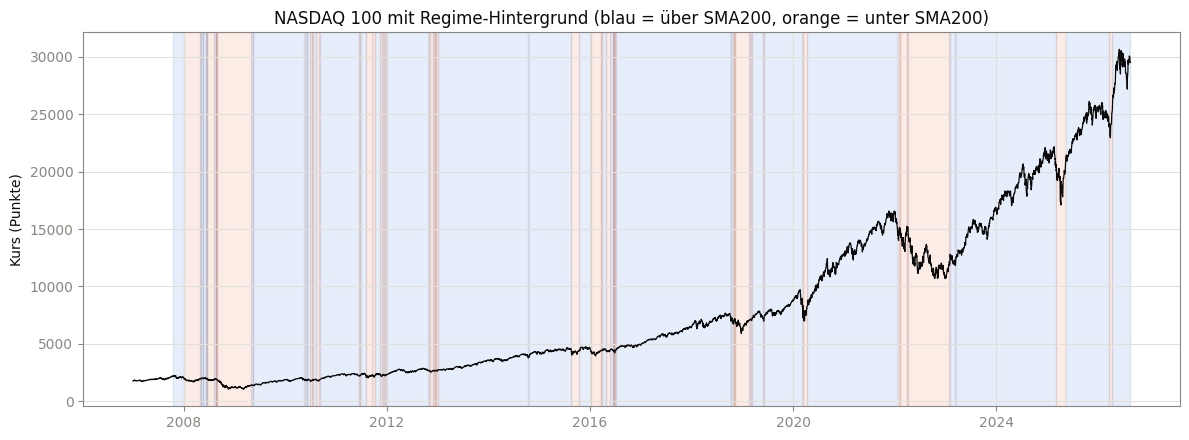

In [19]:
# Kursverlauf mit farblich hinterlegtem Regime-Hintergrund: macht die in
# regime_laufzeiten() gemessenen, teils mehrjährigen Phasen visuell sichtbar.
fig, achse = plt.subplots(figsize=(12, 4.5))
achse.fill_between(df.index, 0, 1, where=über200, color=COLOR_A, alpha=0.12, transform=achse.get_xaxis_transform())
achse.fill_between(df.index, 0, 1, where=unter200, color=COLOR_B, alpha=0.12, transform=achse.get_xaxis_transform())
achse.plot(df.index, df["Close"], color=COLOR_PRICE, linewidth=0.9)
achse.set_ylabel("Kurs (Punkte)")
achse.set_title("NASDAQ 100 mit Regime-Hintergrund (blau = über SMA200, orange = unter SMA200)")
fig.tight_layout()
plt.show()


**Ergänzende Betrachtung – Regime-Laufzeiten:** Seit 2007 wechselte das SMA200-Regime 121-mal, mit einer identischen medianen Phasendauer von 3 Handelstagen in beiden Zuständen – die Mittelwerte liegen jedoch deutlich darüber (16 Handelstage unter, 62 Handelstage über SMA200), da einzelne Phasen mehrere Jahre andauern können (Maximum: 203 bzw. 572 Handelstage). Der niedrige Median deutet auf eine größere Zahl kurzer Regimewechsel hin, während der deutlich höhere Mittelwert bei „über SMA200“ zeigt, dass wenige, sehr lange Aufwärtsphasen (bis zu 572 Handelstage, rund 2,3 Jahre) einen erheblichen Teil der Historie prägen.

**Praxisrelevanz für Börseninvestoren:** Trotz der kurzen medianen Phasendauer summieren sich die wenigen sehr langen Aufwärtsphasen zu einem deutlich größeren Anteil der Handelstage (siehe Abschnitt 7: rund drei Viertel aller Tage seit 2007 notierte der Kurs über dem SMA200). Ein SMA200-basiertes Signal wechselt damit zwar häufiger als der Median allein vermuten lässt, bleibt aber durch die dominanten langen Phasen praktisch anwendbar, ohne ständig zwischen den Zuständen zu flackern.

### 4.2 H2 – SMA-Richtung (steigend oder fallend)

**Hypothese:** Nicht nur die Position des Kurses relativ zum SMA, sondern
auch die Richtung des SMA selbst (steigend oder fallend gegenüber dem
Vortag) trägt Information über die Folgeperiode. Geprüft wird dies analog
zu H1 für SMA20, SMA100 und SMA200.


In [20]:
def regime_gruppen_richtung(sma_fenster: int) -> tuple[pd.Series, pd.Series]:
    # Richtung des SMA (Tagesveränderung) statt seines Niveaus - unabhängig
    # von der Position des Kurses relativ zum SMA (H1).
    sma_diff = df[f"SMA{sma_fenster}_d"].diff()
    valide = sma_diff.notna()
    steigend = (sma_diff > 0) & valide
    fallend = (sma_diff <= 0) & valide
    return steigend, fallend


ergebnisse_h2 = []
for w in SMA_WINDOWS_DAILY:
    steigend, fallend = regime_gruppen_richtung(w)
    for h in HORIZONS:
        for ziel in ["fwd_return", "fwd_mdd"]:
            res = vergleiche_gruppen(
                df.loc[steigend, f"{ziel}_{h}d"], df.loc[fallend, f"{ziel}_{h}d"],
                label_a=f"SMA{w} steigend", label_b=f"SMA{w} fallend",
            )
            if res:
                res.update({"sma_fenster": w, "horizont_tage": h, "zielgröße": ziel})
                ergebnisse_h2.append(res)

tabelle_h2 = ergebnisse_zu_tabelle(ergebnisse_h2)
alle_ergebnisse["H2_SMA_Richtung"] = tabelle_h2
tabelle_h2[spalten_anzeige]


,sma_fenster,horizont_tage,zielgröße,label_a,mean_a,label_b,mean_b,t_pvalue,u_pvalue,signifikant_5pct
0,20,30,fwd_return,SMA20 steigend,0.0160,SMA20 fallend,0.0265,0.0000,0.0000,True
1,20,30,fwd_mdd,SMA20 steigend,-0.0556,SMA20 fallend,-0.0712,0.0000,0.0000,True
2,20,60,fwd_return,SMA20 steigend,0.0337,SMA20 fallend,0.0510,0.0000,0.0000,True
3,20,60,fwd_mdd,SMA20 steigend,-0.0830,SMA20 fallend,-0.0986,0.0000,0.0000,True
4,20,90,fwd_return,SMA20 steigend,0.0527,SMA20 fallend,0.0720,0.0000,0.0000,True
5,20,90,fwd_mdd,SMA20 steigend,-0.1044,SMA20 fallend,-0.1171,0.0000,0.0012,True
6,100,30,fwd_return,SMA100 steigend,0.0180,SMA100 fallend,0.0246,0.0282,0.0004,True
7,100,30,fwd_mdd,SMA100 steigend,-0.0548,SMA100 fallend,-0.0847,0.0000,0.0000,True
8,100,60,fwd_return,SMA100 steigend,0.0362,SMA100 fallend,0.0497,0.0007,0.0001,True
9,100,60,fwd_mdd,SMA100 steigend,-0.0823,SMA100 fallend,-0.1126,0.0000,0.0000,True


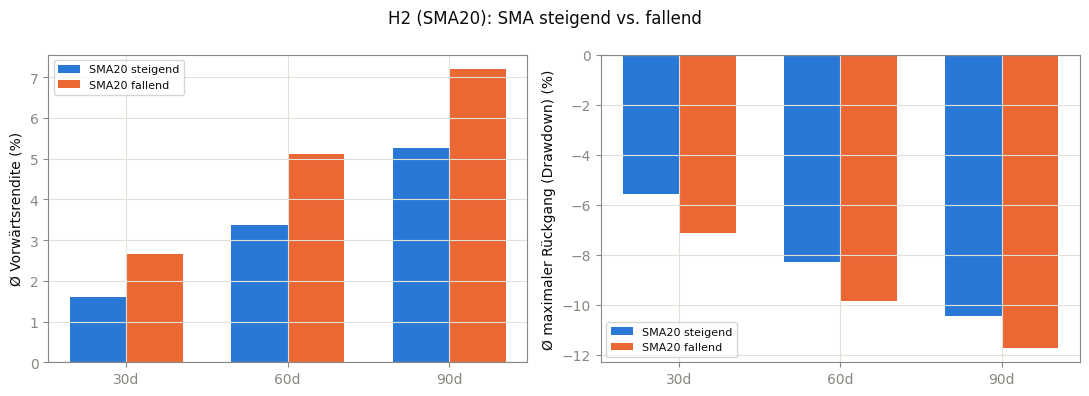

In [21]:
# Stellvertretend für SMA20 - SMA100/SMA200 folgen in den nächsten beiden Zellen
plotte_gruppenvergleich(tabelle_h2[tabelle_h2["sma_fenster"] == 20], "H2 (SMA20): SMA steigend vs. fallend")


**Ergebnis SMA20:** Wie bei H1 zeigt sich ein durchgehend signifikanter, gegenläufiger Zusammenhang: geringeres Risiko bei steigendem SMA20 (90 Tage: −10,4 % gegenüber −11,7 %), gleichzeitig signifikant höhere Rendite bei fallendem SMA20 in allen drei Horizonten (90 Tage: 7,1 % gegenüber 5,3 %).

**Praxisrelevanz für Börseninvestoren:** Die Richtung des kurzfristigen SMA20 bestätigt das bei H1 beobachtete Muster und liefert keine eigenständige zusätzliche Information gegenüber der reinen Kursposition zum SMA20.

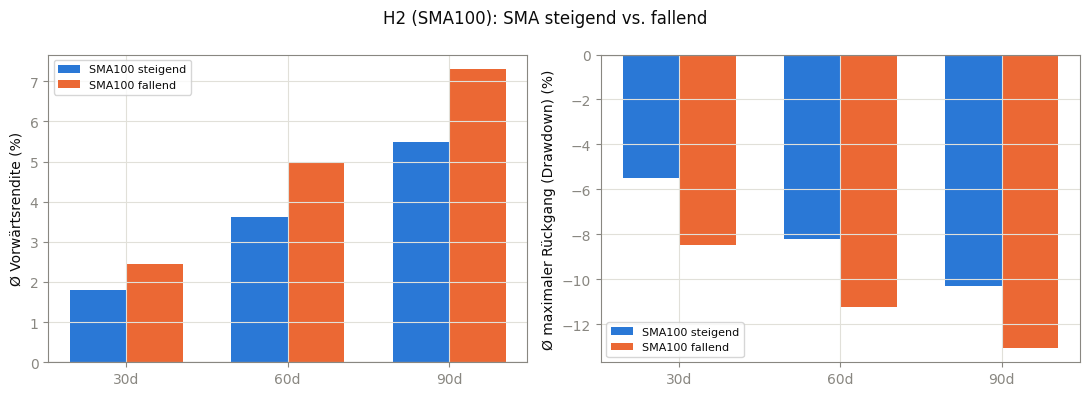

In [22]:
# Gleiche Auswertung wie oben, hier für SMA100
plotte_gruppenvergleich(tabelle_h2[tabelle_h2["sma_fenster"] == 100], "H2 (SMA100): SMA steigend vs. fallend")


**Ergebnis SMA100:** Der Risikounterschied bleibt über alle Horizonte signifikant. Anders als ein rein träges Signal vermuten ließe, bleibt auch der bei SMA20 beobachtete Mean-Reversion-Effekt bei der Rendite über alle drei Horizonte statistisch abgesichert (90 Tage: 7,2 % bei fallendem gegenüber 5,5 % bei steigendem SMA100).

**Praxisrelevanz für Börseninvestoren:** SMA100-Richtung liefert sowohl ein belastbares Risikosignal als auch ein durchgängig signifikantes, wenn auch gegenläufiges Renditesignal – ein Investor sollte einen fallenden SMA100 also nicht als Verkaufssignal für die erwartete Rendite interpretieren, wohl aber als Hinweis auf ein erhöhtes Risiko.

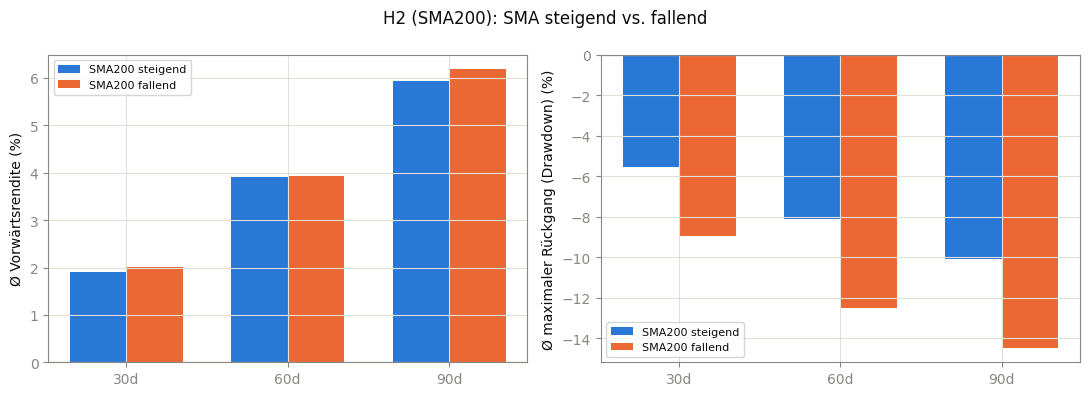

In [23]:
# Gleiche Auswertung wie oben, hier für SMA200
plotte_gruppenvergleich(tabelle_h2[tabelle_h2["sma_fenster"] == 200], "H2 (SMA200): SMA steigend vs. fallend")


**Ergebnis SMA200:** Der Risikounterschied bleibt signifikant (90 Tage: −10,1 % bei steigendem gegenüber −14,5 % bei fallendem SMA200). Die Rendite zeigt kein konsistentes Bild: Bei 30 Tagen liegt die Rendite bei fallendem SMA200 geringfügig höher, bei 60 Tagen sind beide Gruppen mit 3,92 % praktisch identisch, bei 90 Tagen liegt fallend wieder etwas höher – in keinem Fall statistisch signifikant.

**Praxisrelevanz für Börseninvestoren:** Die Richtung des SMA200 eignet sich – wie die Position des Kurses zu SMA200 bei H1 – primär als Risikoindikator, nicht als Renditesignal.

In [24]:
# Regime-Laufzeiten der SMA200-Richtung (analog zu Zelle "regime_laufzeiten" bei
# H1) - dient als zweiter Beleg für die geringe Wechselhäufigkeit
# langfristiger SMA-Zustände.
steigend200, fallend200 = regime_gruppen_richtung(200)
laufzeiten_h2 = regime_laufzeiten(steigend200, fallend200, "SMA200 steigend", "SMA200 fallend")

print(f"Anzahl Regime-Phasen seit 2007 (SMA200-Richtung): {len(laufzeiten_h2)}")
print(laufzeiten_h2.groupby("zustand")["länge"].agg(["count", "median", "mean", "max"]))


Anzahl Regime-Phasen seit 2007 (SMA200-Richtung): 119
                 count  median    mean  max
zustand                                    
SMA200 fallend      59  2.0000 13.9831  271
SMA200 steigend     60  4.0000 65.1667  642


**Ergänzende Betrachtung – Regime-Laufzeiten:** Die Richtung des SMA200 wechselte seit 2007 119-mal – geringfügig seltener als die Kursposition zu SMA200 bei H1 (121 Wechsel), der Unterschied fällt hier deutlich kleiner aus als bei einem stark trägeren Signal zu erwarten wäre. Steigende Phasen dauerten im Mittel deutlich länger an (bis zu 642 Handelstage, rund 2,5 Jahre) als fallende Phasen (bis zu 271 Handelstage); der Median liegt bei 4 (steigend) bzw. 2 (fallend) Handelstagen.

**Praxisrelevanz für Börseninvestoren:** Trotz der nur geringfügig geringeren Wechselhäufigkeit gegenüber H1 zeigt die deutlich längere maximale Dauer steigender Phasen, dass die SMA200-Richtung von wenigen, aber sehr lang anhaltenden Aufwärtsphasen geprägt ist – ein Umstand, der sie für längerfristig orientierte Investoren praktikabel macht, auch wenn sie als eigenständiges taktisches Signal keinen Mehrwert gegenüber H1 bietet.

### 4.3 H3 – Cross-Over (Golden Cross / Death Cross)

**Hypothese:** Das Kreuzen eines kurzfristigen SMA über einen langfristigen
SMA von unten nach oben (**Golden Cross**) bzw. von oben nach unten
(**Death Cross**) gilt als klassisches technisches Signal. Geprüft werden
alle neun möglichen SMA-Paare über Tages-, Wochen- und Monatsbasis.


In [25]:
def finde_crossover(sma_kurz: pd.Series, sma_lang: pd.Series) -> tuple[pd.Series, pd.Series]:
    # Golden Cross: kurzer SMA kreuzt den langen SMA von unten nach oben.
    # Death Cross: umgekehrte Richtung. shift(1) vergleicht mit dem Vortag,
    # damit nur der tatsächliche Kreuzungstag markiert wird, nicht jeder Tag
    # der jeweiligen Lage.
    golden = (sma_kurz.shift(1) <= sma_lang.shift(1)) & (sma_kurz > sma_lang)
    death = (sma_kurz.shift(1) >= sma_lang.shift(1)) & (sma_kurz < sma_lang)
    return golden, death


# Alle neun sinnvollen SMA-Paare je Zeitbasis (kurzes vor langem Fenster)
crossover_paare = [
    (20, 100, "d"), (20, 200, "d"), (100, 200, "d"),
    (20, 100, "w"), (20, 200, "w"), (100, 200, "w"),
    (20, 50, "m"), (20, 75, "m"), (50, 75, "m"),
]

ergebnisse_h3 = []
for kurz, lang, basis in crossover_paare:
    golden, death = finde_crossover(df[f"SMA{kurz}_{basis}"], df[f"SMA{lang}_{basis}"])
    n_golden, n_death = int(golden.sum()), int(death.sum())

    for h in HORIZONS:
        for ziel in ["fwd_return", "fwd_mdd"]:
            res = vergleiche_gruppen(
                df.loc[golden, f"{ziel}_{h}d"], df.loc[death, f"{ziel}_{h}d"],
                label_a=f"Golden Cross SMA{kurz}/{lang} ({basis})", label_b=f"Death Cross SMA{kurz}/{lang} ({basis})",
            )
            if res:
                res.update({"zeitbasis": basis, "sma_kurz": kurz, "sma_lang": lang,
                            "n_golden_events": n_golden, "n_death_events": n_death,
                            "horizont_tage": h, "zielgröße": ziel})
                ergebnisse_h3.append(res)

tabelle_h3 = ergebnisse_zu_tabelle(ergebnisse_h3)
alle_ergebnisse["H3_CrossOver"] = tabelle_h3
cols_h3 = ["zeitbasis", "sma_kurz", "sma_lang", "n_golden_events", "n_death_events", "horizont_tage",
           "zielgröße", "mean_a", "mean_b", "t_pvalue", "u_pvalue", "signifikant_5pct"]
tabelle_h3[cols_h3]


,zeitbasis,sma_kurz,sma_lang,n_golden_events,n_death_events,horizont_tage,zielgröße,mean_a,mean_b,t_pvalue,u_pvalue,signifikant_5pct
0,d,20,100,21,21,30,fwd_return,0.0194,0.0315,0.5553,0.8999,False
1,d,20,100,21,21,30,fwd_mdd,-0.0550,-0.0683,0.3089,0.1280,False
2,d,20,100,21,21,60,fwd_return,0.0317,0.0608,0.4008,0.3924,False
3,d,20,100,21,21,60,fwd_mdd,-0.0798,-0.1014,0.2420,0.2629,False
4,d,20,100,21,21,90,fwd_return,0.0677,0.0860,0.6762,0.6860,False
5,d,20,100,21,21,90,fwd_mdd,-0.0918,-0.1146,0.3426,0.5312,False
6,d,20,200,17,17,30,fwd_return,0.0182,0.0402,0.5850,0.8633,False
7,d,20,200,17,17,30,fwd_mdd,-0.0636,-0.0776,0.5807,0.3096,False
8,d,20,200,17,17,60,fwd_return,0.0411,0.0771,0.5221,0.5128,False
9,d,20,200,17,17,60,fwd_mdd,-0.0914,-0.1091,0.5963,0.3013,False


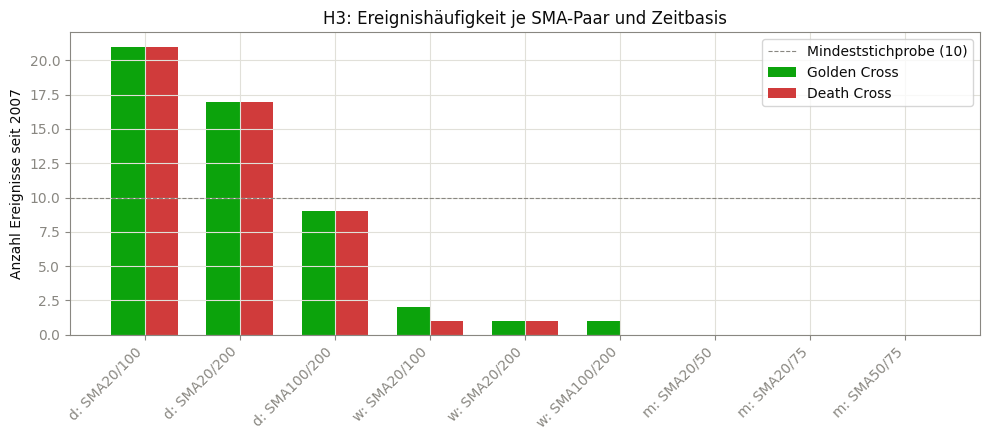

In [26]:
# Ereignishäufigkeit je Paar/Zeitbasis - zeigt, welche Paare überhaupt genug
# Beobachtungen für einen belastbaren Test liefern (vergleiche_gruppen()
# verlangt implizit mind. 10 Ereignisse je Gruppe).
übersicht_ereignisse = []
for kurz, lang, basis in crossover_paare:
    golden, death = finde_crossover(df[f"SMA{kurz}_{basis}"], df[f"SMA{lang}_{basis}"])
    übersicht_ereignisse.append({"zeitbasis": basis, "paar": f"SMA{kurz}/{lang}",
                                   "n_golden": int(golden.sum()), "n_death": int(death.sum())})
tabelle_ereignisse_h3 = pd.DataFrame(übersicht_ereignisse)

fig, achse = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(tabelle_ereignisse_h3))
breite = 0.35
etiketten = [f"{r.zeitbasis}: {r.paar}" for r in tabelle_ereignisse_h3.itertuples()]
achse.bar(x - breite / 2, tabelle_ereignisse_h3["n_golden"], breite, label="Golden Cross", color=COLOR_GOOD)
achse.bar(x + breite / 2, tabelle_ereignisse_h3["n_death"], breite, label="Death Cross", color=COLOR_BAD)
achse.axhline(10, color=COLOR_MUTED, linewidth=0.8, linestyle="--", label="Mindeststichprobe (10)")
achse.set_xticks(x)
achse.set_xticklabels(etiketten, rotation=45, ha="right")
achse.set_ylabel("Anzahl Ereignisse seit 2007")
achse.legend()
plt.title("H3: Ereignishäufigkeit je SMA-Paar und Zeitbasis")
plt.tight_layout()
plt.show()


**Ergebnis – Ereignishäufigkeit:** Von neun geprüften Paaren erreichen nur zwei die Mindeststichprobe von 10 Ereignissen je Richtung – beide auf Tagesbasis (SMA20/100 mit 21/21, SMA20/200 mit 17/17 Ereignissen). Das dritte Tagesbasis-Paar (SMA100/200) verfehlt die Schwelle knapp mit 9/9 Ereignissen. Alle Wochen- und Monatsbasis-Paare liegen im Bereich von 0 bis 2 Ereignissen über den gesamten Analysezeitraum von rund 19 Jahren und sind damit für eine statistische Aussage nicht geeignet.

**Praxisrelevanz für Börseninvestoren:** Cross-Over-Signale auf Wochen- oder Monatsbasis, wie sie in der Praxis gelegentlich als „robustere“ Variante des klassischen Signals beworben werden, treten in diesem Datensatz zu selten auf, um überhaupt eine belastbare Handelsregel zu begründen – selbst das dritte Tagesbasis-Paar verfehlt die Mindeststichprobe nur knapp.

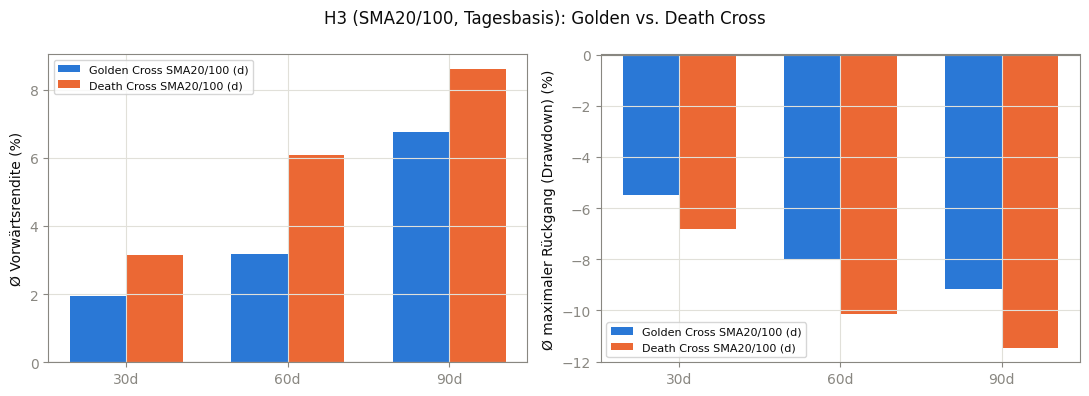

In [27]:
# Häufigstes testbares Paar (Tagesbasis)
teil_20_100 = tabelle_h3[(tabelle_h3["sma_kurz"] == 20) & (tabelle_h3["sma_lang"] == 100) & (tabelle_h3["zeitbasis"] == "d")]
plotte_gruppenvergleich(teil_20_100, "H3 (SMA20/100, Tagesbasis): Golden vs. Death Cross")


**Ergebnis SMA20/100 (Tagesbasis, 21/21 Ereignisse):** Trotz der mit 21 Ereignissen je Richtung vergleichsweise umfangreichen Stichprobe ist in keinem der sechs geprüften Kombinationen (drei Horizonte × zwei Zielgrößen) ein statistisch signifikanter Unterschied zwischen Golden und Death Cross nachweisbar.

**Praxisrelevanz für Börseninvestoren:** Für dieses – in der Praxis häufig verwendete – SMA-Paar liefert das klassische Cross-Over-Signal in den vorliegenden Daten keinen statistisch abgesicherten Handlungshinweis; weder für die erwartete Rendite noch für das Risiko.

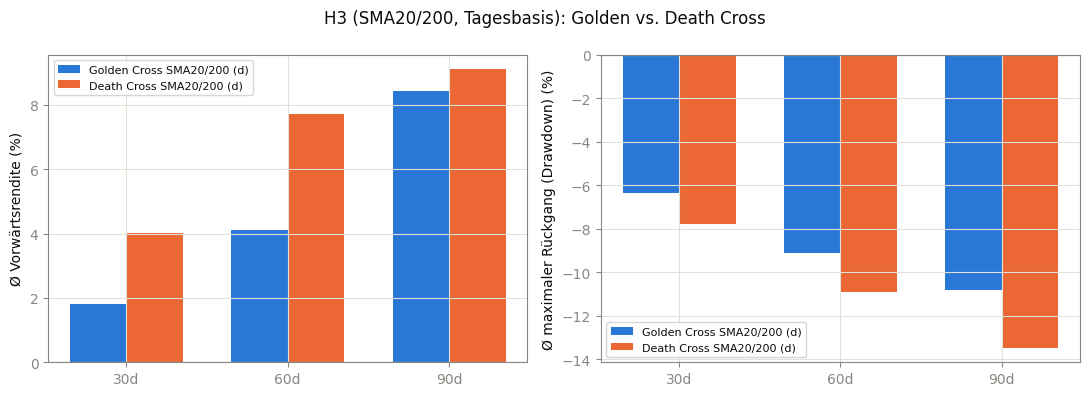

In [28]:
# Selteneres der beiden testbaren Paare (Tagesbasis)
teil_20_200 = tabelle_h3[(tabelle_h3["sma_kurz"] == 20) & (tabelle_h3["sma_lang"] == 200) & (tabelle_h3["zeitbasis"] == "d")]
plotte_gruppenvergleich(teil_20_200, "H3 (SMA20/200, Tagesbasis): Golden vs. Death Cross")


**Ergebnis SMA20/200 (Tagesbasis, 17/17 Ereignisse):** Bei diesem selteneren Paar liegt die mittlere Rendite nach einem Death Cross im 90-Tage-Horizont zwar numerisch höher als nach einem Golden Cross (9,1 % gegenüber 8,4 %) – statistisch bestätigt sich dieser Unterschied jedoch in keinem der sechs geprüften Kombinationen, weder bei der Rendite noch beim maximalen Rückgang.

**Praxisrelevanz für Börseninvestoren:** Damit liefert keines der beiden testbaren Cross-Over-Paare ein statistisch abgesichertes Signal – weder das häufigere SMA20/100- noch das seltenere SMA20/200-Paar. Das klassische Golden-/Death-Cross-Signal ist für den NASDAQ 100 unabhängig vom gewählten Paar eigenständig nicht ausreichend statistisch abgesichert.

### 4.4 H4 – Divergenz zwischen kurz- und längerfristigem Trend

**Hypothese:** Ein kurzfristiger Rücksetzer innerhalb eines intakten
längerfristigen Aufwärtstrends könnte eine überdurchschnittlich günstige
Ausgangslage markieren. Geprüft werden zwei Divergenzmuster (jeweils mit
SMA20, dem empfindlichsten Fenster):

- **D1 (Tages-/Wochenbasis):** Der Tages-SMA20 fällt mindestens fünf
  Handelstage in Folge, während der Wochen-SMA20 gleichzeitig steigt, und
  der Tages-SMA20 beginnt anschließend wieder zu steigen.
- **D2 (Wochen-/Monatsbasis):** dieselbe Logik eine Zeitebene höher: der
  Wochen-SMA20 fällt mindestens fünf Wochen in Folge, während der
  Monats-SMA20 gleichzeitig steigt.


In [29]:
def konsekutive_rückgangs_länge(s: pd.Series) -> pd.Series:
    # Zählt für jeden Tag, wie viele Tage in Folge die Reihe bis dahin bereits
    # gefallen ist (0, falls der Vortag nicht gefallen ist) - Basis für das
    # "mindestens 5 Tage in Folge fallend"-Kriterium von D1/D2.
    fällt = s.diff() < 0
    gruppe = (~fällt).cumsum()
    return fällt.astype(int).groupby(gruppe).cumsum()


sma_d = df["SMA20_d"]
sma_w = df["SMA20_w"]

rückgangs_länge_d = konsekutive_rückgangs_länge(sma_d).shift(1)
tages_sma_dreht_wieder = sma_d.diff() > 0
wochen_sma_steigt = sma_w.diff() > 0

# D1-Ereignis: Tages-SMA20 dreht nach mind. 5 Tagen Rückgang wieder nach
# oben, während der übergeordnete Wochen-SMA20 währenddessen weiter steigt.
event_d1 = tages_sma_dreht_wieder & (rückgangs_länge_d >= 5) & wochen_sma_steigt
print(f"D1-Ereignisse identifiziert: {int(event_d1.sum())}")

ergebnisse_h4 = []
for h in HORIZONS:
    for ziel in ["fwd_return", "fwd_mdd"]:
        res = vergleiche_gruppen(
            df.loc[event_d1, f"{ziel}_{h}d"], df[f"{ziel}_{h}d"],
            label_a="D1-Signal (Tage/Woche)", label_b="Basisrate (alle Tage)",
        )
        if res:
            res.update({"muster": "D1_tage_woche", "horizont_tage": h, "zielgröße": ziel, "n_events": int(event_d1.sum())})
            ergebnisse_h4.append(res)


D1-Ereignisse identifiziert: 9


In [30]:
# D2 wird auf nativer Wochen-/Monatsbasis berechnet (statt wie D1 über die
# auf Tagesbasis gemappten Spalten), damit "5 Wochen in Folge fallend" exakt
# der fachlichen Definition entspricht und nicht durch das Mapping auf
# Handelstage verzerrt wird.
wochenschluss_nativ = df["Close"].resample("W-FRI").last().dropna()
wochen_sma_nativ = wochenschluss_nativ.rolling(20, min_periods=20).mean()

monatsschluss_nativ = df["Close"].resample("ME").last().dropna()
monats_sma_nativ = monatsschluss_nativ.rolling(20, min_periods=20).mean()

monat_auf_woche = pd.merge_asof(
    wochen_sma_nativ.reset_index()[["Date"]],
    monats_sma_nativ.rename("monat_sma").reset_index(),
    on="Date", direction="backward",
)["monat_sma"]
monat_auf_woche.index = wochen_sma_nativ.index

rückgangs_länge_w = konsekutive_rückgangs_länge(wochen_sma_nativ).shift(1)
wochen_sma_dreht_wieder = wochen_sma_nativ.diff() > 0
monat_sma_steigt = monat_auf_woche.diff() > 0

# D2-Ereignis: gleiche Logik wie D1, eine Zeitebene höher (Woche/Monat statt Tag/Woche)
event_d2_wöchentlich = wochen_sma_dreht_wieder & (rückgangs_länge_w >= 5) & monat_sma_steigt
print(f"D2-Ereignisse identifiziert (Wochenbasis): {int(event_d2_wöchentlich.sum())}")

# Wochenbasierte Ereignistermine auf den jeweils folgenden Handelstag
# gemappt, damit sie mit den tagesbasierten fwd_-Zielgrößen verglichen werden können.
event_d2_termine = event_d2_wöchentlich[event_d2_wöchentlich].index
if len(event_d2_termine) > 0:
    d2_auf_tage = pd.merge_asof(
        pd.DataFrame({"Date": event_d2_termine}).sort_values("Date"),
        df.reset_index()[["Date"]], on="Date", direction="forward",
    )["Date"]
    event_d2_täglich = df.index.isin(d2_auf_tage)
else:
    event_d2_täglich = pd.Series(False, index=df.index)

for h in HORIZONS:
    for ziel in ["fwd_return", "fwd_mdd"]:
        res = vergleiche_gruppen(
            df.loc[event_d2_täglich, f"{ziel}_{h}d"], df[f"{ziel}_{h}d"],
            label_a="D2-Signal (Woche/Monat)", label_b="Basisrate (alle Tage)",
        )
        if res:
            res.update({"muster": "D2_woche_monat", "horizont_tage": h, "zielgröße": ziel, "n_events": int(event_d2_täglich.sum())})
            ergebnisse_h4.append(res)

tabelle_h4 = ergebnisse_zu_tabelle(ergebnisse_h4)
cols_h4 = ["muster", "n_events", "horizont_tage", "zielgröße", "mean_a", "mean_b", "t_pvalue", "u_pvalue", "signifikant_5pct"]
# Falls kein einziges Muster (D1 oder D2) die Mindeststichprobe erreicht,
# liefert ergebnisse_zu_tabelle() einen leeren DataFrame ohne die erwarteten
# Spalten - reindex() stellt die Spaltenstruktur auch in diesem Fall sicher,
# ohne das Prüfkriterium selbst zu verändern.
tabelle_h4 = tabelle_h4.reindex(columns=cols_h4) if tabelle_h4.empty else tabelle_h4
alle_ergebnisse["H4_Divergenz"] = tabelle_h4
tabelle_h4[cols_h4]


D2-Ereignisse identifiziert (Wochenbasis): 2


,muster,n_events,horizont_tage,zielgröße,mean_a,mean_b,t_pvalue,u_pvalue,signifikant_5pct


**Ergebnis D2:** Mit lediglich zwei identifizierten Ereignissen seit 2007 liegt D2 deutlich unterhalb der Mindeststichprobe von 10 Beobachtungen und wird aus diesem Grund nicht statistisch getestet und nicht grafisch ausgewertet – eine Auswertung auf Basis von zwei Einzelfällen wäre nicht belastbar.

**Praxisrelevanz für Börseninvestoren:** Je höher die betrachtete Zeitebene, desto seltener tritt das Divergenzmuster auf. Für ein Divergenzsignal auf Wochen-/Monatsbasis liegt in fast zwei Jahrzehnten schlicht nicht genügend Historie vor, um es als Entscheidungsgrundlage heranzuziehen.

In [31]:
# D2 wird hier bewusst nicht abgebildet (nur wenige Ereignisse, siehe Ergebnistext).
# D1 wird nur dann grafisch ausgewertet, wenn mindestens eine Parameterkombination
# die Mindeststichprobe von 10 Beobachtungen je Gruppe erreicht hat - für den
# NASDAQ 100 ist das nicht der Fall (siehe Ergebnistext).
tabelle_d1 = tabelle_h4[tabelle_h4["muster"] == "D1_tage_woche"] if "muster" in tabelle_h4.columns else tabelle_h4.iloc[0:0]
if len(tabelle_d1) > 0:
    plotte_gruppenvergleich(tabelle_d1, "H4 (D1, Tages-/Wochenbasis): Divergenz-Signal vs. Basisrate")
else:
    print("H4 (D1): Mindeststichprobe von 10 Ereignissen je Gruppe nicht erreicht - keine grafische Auswertung.")


H4 (D1): Mindeststichprobe von 10 Ereignissen je Gruppe nicht erreicht - keine grafische Auswertung.


**Ergebnis D1 (9 Ereignisse):** Das D1-Muster identifiziert für den NASDAQ 100 nur 9 Ereignisse seit 2007 und verfehlt damit knapp die Mindeststichprobe von 10 Beobachtungen je Gruppe. Wie bei D2 wird daher auch für D1 kein Signifikanztest durchgeführt und keine grafische Auswertung erstellt.

**Praxisrelevanz für Börseninvestoren:** Für den NASDAQ 100 ist damit keines der beiden geprüften Divergenzmuster (D1, D2) statistisch testbar. H4 liefert für diesen Index ausschließlich einen deskriptiven, keinen statistisch abgesicherten Hinweis und eignet sich schon aus diesem Grund nicht als Baustein für ein Ampelsystem.

### 4.5 H5 – Abstand vom bisherigen Hoch (Drawdown-Status)

**Hypothese:** Der prozentuale Abstand des aktuellen Kurses zu seinem
bisherigen Höchststand (Allzeithoch) liefert Information über die
Folgeperiode – unabhängig von einer SMA-Fensterwahl. Diese Kennzahl
entspricht der in der Praxis gebräuchlichen Korrektur- (ab −10 %) und
Bärenmarkt-Definition (ab −20 %).


In [32]:
# Allzeithoch als laufendes Maximum des Schlusskurses; Abstand_vom_Hoch ist
# damit unabhängig von jeder SMA-Fensterwahl und entspricht der in der Praxis
# gebräuchlichen Korrektur-/Bärenmarkt-Definition.
df["Allzeithoch"] = df["Close"].cummax()
df["Abstand_vom_Hoch"] = df["Close"] / df["Allzeithoch"] - 1


def drawdown_bucket(x: float) -> str:
    # Vier Stufen entlang gängiger Marktdefinitionen: Korrektur ab -10 %, Bärenmarkt ab -20 %
    if x >= -0.05:
        return "Nahe am Hoch (0 bis -5%)"
    elif x >= -0.10:
        return "Leichte Korrektur (-5 bis -10%)"
    elif x >= -0.20:
        return "Korrektur (-10 bis -20%)"
    else:
        return "Bärenmarkt (< -20%)"


df["Drawdown_Bucket"] = df["Abstand_vom_Hoch"].apply(drawdown_bucket)
bucket_reihenfolge = ["Nahe am Hoch (0 bis -5%)", "Leichte Korrektur (-5 bis -10%)",
                       "Korrektur (-10 bis -20%)", "Bärenmarkt (< -20%)"]
print("Verteilung der Handelstage auf die vier Drawdown-Stufen:")
print(df["Drawdown_Bucket"].value_counts().reindex(bucket_reihenfolge))


Verteilung der Handelstage auf die vier Drawdown-Stufen:
Drawdown_Bucket
Nahe am Hoch (0 bis -5%)           2860
Leichte Korrektur (-5 bis -10%)     792
Korrektur (-10 bis -20%)            643
Bärenmarkt (< -20%)                 640
Name: count, dtype: int64


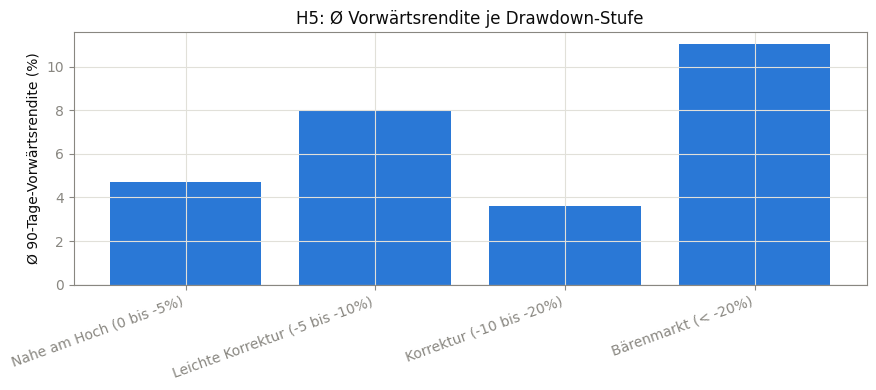

In [33]:
# Mittlere 90-Tage-Vorwärtsrendite je Drawdown-Stufe
übersicht = df.groupby("Drawdown_Bucket")[["fwd_return_90d", "fwd_mdd_90d"]].mean().reindex(bucket_reihenfolge)
fig, achse = plt.subplots(figsize=(9, 4))
achse.bar(übersicht.index, übersicht["fwd_return_90d"] * 100, color=COLOR_A)
achse.set_ylabel("Ø 90-Tage-Vorwärtsrendite (%)")
achse.axhline(0, color=COLOR_MUTED, linewidth=0.8)
plt.xticks(rotation=20, ha="right")
plt.title("H5: Ø Vorwärtsrendite je Drawdown-Stufe")
plt.tight_layout()
plt.show()


**Ergebnis – Verteilung und Rendite je Stufe:** Rund 58 % der Handelstage seit 2007 lagen innerhalb von 5 % des bisherigen Hochs, während rund 13 % der Handelstage einem Bärenmarkt (Rückgang über 20 %) zuzuordnen sind. Die mittlere 90-Tage-Vorwärtsrendite steigt dabei nicht gleichmäßig mit der Tiefe der Korrektur: Sie liegt in der Stufe „Nahe am Hoch“ bei 4,7 %, steigt in der „Leichten Korrektur“ auf 7,9 %, fällt in der Stufe „Korrektur“ auf 3,6 % zurück und erreicht mit 11,0 % ihren höchsten Wert erst in der Stufe „Bärenmarkt“. Auch der mittlere 90-Tage-Vorwärts-Drawdown verläuft nicht monoton: Er ist in der Stufe „Korrektur“ mit −14,9 % am stärksten ausgeprägt und in der tiefsten Stufe „Bärenmarkt“ mit −12,2 % wieder etwas geringer.

**Praxisrelevanz für Börseninvestoren:** Bereits die reine Häufigkeitsverteilung ist informativ: Tiefere Korrekturphasen sind kein Randphänomen, sondern machen mit rund einem Viertel der Handelstage (Korrektur- und Bärenmarktstufe zusammen) einen erheblichen Teil der Historie aus. Das nicht-monotone Renditemuster – der höchste erwartete Wert liegt ausgerechnet in der tiefsten Stufe – deutet darauf hin, dass sich der NASDAQ 100 aus ausgeprägten Bärenmärkten historisch besonders kräftig erholt hat, während die mittlere Korrekturstufe eher eine Übergangsphase mit anhaltendem Abwärtsdruck markiert.

In [34]:
# Vergleich der beiden äußeren Drawdown-Stufen (nahe am Hoch vs. spürbare
# Korrektur) - die beiden mittleren Übergangsstufen werden hier ausgespart,
# um einen möglichst trennscharfen Test zu erhalten.
nahe_am_hoch = df["Abstand_vom_Hoch"] >= -0.05
spürbare_korrektur = df["Abstand_vom_Hoch"] < -0.10

ergebnisse_h5 = []
for h in HORIZONS:
    for ziel in ["fwd_return", "fwd_mdd"]:
        res = vergleiche_gruppen(
            df.loc[nahe_am_hoch, f"{ziel}_{h}d"], df.loc[spürbare_korrektur, f"{ziel}_{h}d"],
            label_a="Nahe am Hoch (bis -5%)", label_b="Spürbare Korrektur (>= -10%)",
        )
        if res:
            res.update({"horizont_tage": h, "zielgröße": ziel})
            ergebnisse_h5.append(res)

tabelle_h5 = ergebnisse_zu_tabelle(ergebnisse_h5)
alle_ergebnisse["H5_Drawdown_vom_Hoch"] = tabelle_h5
tabelle_h5[spalten_anzeige_einfach]


,horizont_tage,zielgröße,label_a,mean_a,label_b,mean_b,t_pvalue,u_pvalue,signifikant_5pct
0,30,fwd_return,Nahe am Hoch (bis -5%),0.0133,Spürbare Korrektur (>= -10%),0.0260,0.0000,0.0000,True
1,30,fwd_mdd,Nahe am Hoch (bis -5%),-0.0523,Spürbare Korrektur (>= -10%),-0.0824,0.0000,0.0000,True
2,60,fwd_return,Nahe am Hoch (bis -5%),0.0299,Spürbare Korrektur (>= -10%),0.0499,0.0000,0.0000,True
3,60,fwd_mdd,Nahe am Hoch (bis -5%),-0.0788,Spürbare Korrektur (>= -10%),-0.1146,0.0000,0.0000,True
4,90,fwd_return,Nahe am Hoch (bis -5%),0.0473,Spürbare Korrektur (>= -10%),0.0730,0.0000,0.0000,True
5,90,fwd_mdd,Nahe am Hoch (bis -5%),-0.0993,Spürbare Korrektur (>= -10%),-0.1354,0.0000,0.0000,True


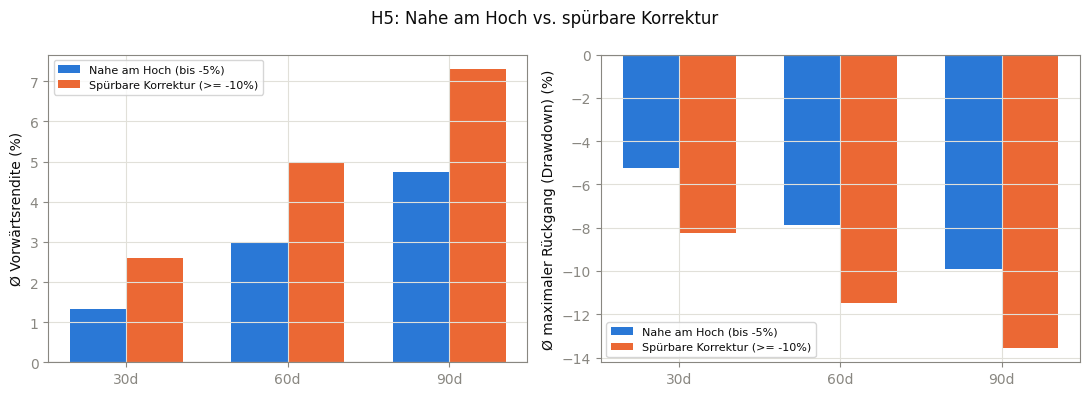

In [35]:
plotte_gruppenvergleich(tabelle_h5, "H5: Nahe am Hoch vs. spürbare Korrektur")


**Ergebnis – Signifikanztest:** Sowohl der maximale Rückgang als auch die Rendite unterscheiden sich in allen drei Horizonten statistisch signifikant zwischen einer Phase nahe am Hoch und einer spürbaren Korrektur (mindestens 10 % unter dem Hoch). Der maximale Rückgang ist aus einer Korrektur heraus durchgängig deutlich größer (90 Tage: −13,5 % gegenüber −9,9 %) – Korrekturen setzen sich demnach tendenziell fort. Bei der Rendite zeigt sich das entgegengesetzte, aber ebenfalls durchgängig signifikante Muster: Aus einer spürbaren Korrektur heraus lag die mittlere Rendite in allen drei Horizonten höher (90 Tage: 7,3 % gegenüber 4,7 %).

**Praxisrelevanz für Börseninvestoren:** Der Drawdown-Status eignet sich als objektive, leicht kommunizierbare Risikokennzahl ohne Parameterentscheidung. Für die Renditeerwartung zeigt sich ein durchgängig signifikanter Mean-Reversion-Effekt über alle drei Horizonte: Ein tieferer Rückgang ging historisch nicht mit einer schlechteren, sondern mit einer statistisch klar höheren erwarteten Rendite einher – allerdings bei gleichzeitig ebenfalls signifikant höherem Risiko eines weiteren Rückgangs.

### 4.6 H6 – Momentum (RSI)

**Hypothese:** Der Relative Strength Index (RSI) misst auf einer Skala von
0 bis 100 das Verhältnis von Aufwärts- zu Abwärtsbewegungen der letzten 14
Handelstage. Werte über 70 gelten klassisch als "überkauft", Werte unter
30 als "überverkauft" – mit der Erwartung einer nachfolgenden
Gegenbewegung.


In [36]:
def berechne_rsi(close: pd.Series, fenster: int = 14) -> pd.Series:
    # Klassischer RSI nach Wilder: exponentiell geglättetes Verhältnis von
    # durchschnittlichen Kursgewinnen zu -verlusten, auf eine Skala von 0-100
    # transformiert.
    delta = close.diff()
    gewinn = delta.clip(lower=0)
    verlust = -delta.clip(upper=0)
    avg_gewinn = gewinn.ewm(alpha=1 / fenster, min_periods=fenster, adjust=False).mean()
    avg_verlust = verlust.ewm(alpha=1 / fenster, min_periods=fenster, adjust=False).mean()
    rs = avg_gewinn / avg_verlust
    return 100 - (100 / (1 + rs))


df["RSI14"] = berechne_rsi(df["Close"], 14)

# Klassische RSI-Schwellenwerte: >70 gilt als überkauft, <30 als überverkauft
überkauft = df["RSI14"] > 70
überverkauft = df["RSI14"] < 30
neutral = df["RSI14"].between(30, 70)
print(f"Überkauft (RSI>70): {int(überkauft.sum())} Tage | "
      f"Neutral (30-70): {int(neutral.sum())} Tage | "
      f"Überverkauft (RSI<30): {int(überverkauft.sum())} Tage")


Überkauft (RSI>70): 556 Tage | Neutral (30-70): 4310 Tage | Überverkauft (RSI<30): 55 Tage


In [37]:
ergebnisse_h6 = []
for h in HORIZONS:
    for ziel in ["fwd_return", "fwd_mdd"]:
        res = vergleiche_gruppen(
            df.loc[überkauft, f"{ziel}_{h}d"], df.loc[überverkauft, f"{ziel}_{h}d"],
            label_a="Überkauft (RSI > 70)", label_b="Überverkauft (RSI < 30)",
        )
        if res:
            res.update({"horizont_tage": h, "zielgröße": ziel})
            ergebnisse_h6.append(res)

tabelle_h6 = ergebnisse_zu_tabelle(ergebnisse_h6)
alle_ergebnisse["H6_Momentum_RSI"] = tabelle_h6
tabelle_h6[spalten_anzeige_einfach]


,horizont_tage,zielgröße,label_a,mean_a,label_b,mean_b,t_pvalue,u_pvalue,signifikant_5pct
0,30,fwd_return,Überkauft (RSI > 70),0.0094,Überverkauft (RSI < 30),0.0092,0.9903,0.5050,False
1,30,fwd_mdd,Überkauft (RSI > 70),-0.0543,Überverkauft (RSI < 30),-0.1066,0.0000,0.0000,True
2,60,fwd_return,Überkauft (RSI > 70),0.0157,Überverkauft (RSI < 30),0.0581,0.0248,0.0013,True
3,60,fwd_mdd,Überkauft (RSI > 70),-0.0877,Überverkauft (RSI < 30),-0.1290,0.0026,0.0019,True
4,90,fwd_return,Überkauft (RSI > 70),0.0322,Überverkauft (RSI < 30),0.0811,0.0310,0.0014,True
5,90,fwd_mdd,Überkauft (RSI > 70),-0.1059,Überverkauft (RSI < 30),-0.1407,0.0127,0.0941,False


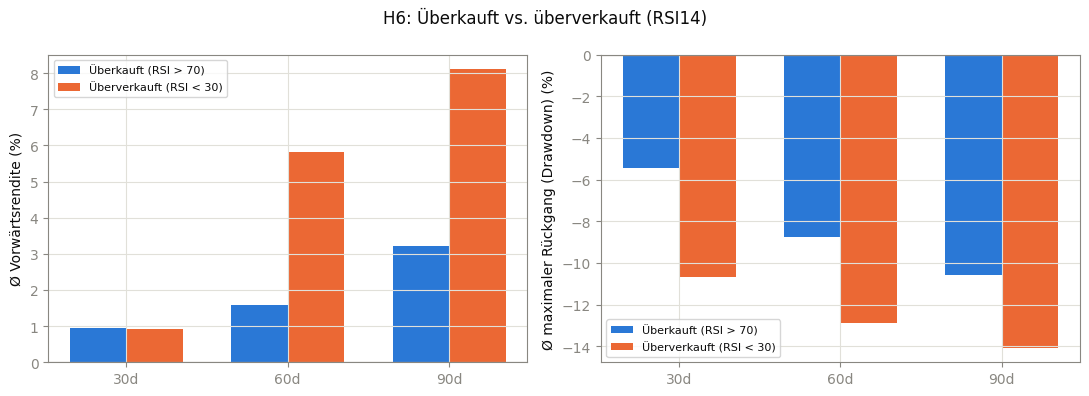

In [38]:
plotte_gruppenvergleich(tabelle_h6, "H6: Überkauft vs. überverkauft (RSI14)")


**Ergebnis:** Die klassische RSI-Interpretation bestätigt sich in den vorliegenden Daten nicht. Nach überverkauften Phasen (RSI < 30) war die mittlere Rendite in zwei der drei Horizonte (60 und 90 Tage) signifikant höher als nach überkauften Phasen (RSI > 70); beim kürzesten Horizont (30 Tage) unterscheiden sich beide Gruppen kaum (0,9 % in beiden Fällen). Der mittlere maximale Rückgang war nach überverkauften Phasen in zwei der drei Horizonte (30 und 60 Tage) signifikant größer; beim längsten Horizont (90 Tage) ist der Unterschied trotz eines deutlich negativeren Mittelwerts (−14,1 % gegenüber −10,6 %) knapp nicht mehr in beiden Tests abgesichert.

**Praxisrelevanz für Börseninvestoren:** Ein stark überverkaufter Markt sollte auf Basis dieser Daten nicht als „sichere Kaufgelegenheit“ interpretiert werden, wie es die klassische RSI-Lehrmeinung nahelegt – tatsächlich war eine überverkaufte Marktlage historisch mit einem tendenziell höheren, in der Mehrheit der Horizonte auch statistisch abgesicherten Risiko verbunden, bei gleichzeitig überwiegend höherer Rendite. RSI eignet sich damit eher als Hinweis auf eine erhöhte Risikolage bei extremen Werten denn als eigenständiges Umkehrsignal.

### 4.7 Übergreifende Robustheitsübersicht

Zur zusammenfassenden Einordnung wird für jede Hypothese der Anteil der
getesteten Parameterkombinationen ausgewiesen, für den ein statistisch
signifikantes Ergebnis vorliegt – getrennt nach Rendite und Risiko.


In [39]:
# Anteil signifikanter Parameterkombinationen je Hypothese und Zielgröße -
# fasst die Robustheit über alle in Abschnitt 4 geprüften Parametrisierungen
# in einer einzigen Kennzahl zusammen.
robustheit = []
for name, tabelle in alle_ergebnisse.items():
    for ziel in ["fwd_return", "fwd_mdd"]:
        teil = tabelle[tabelle["zielgröße"] == ziel]
        if len(teil) == 0:
            continue
        robustheit.append({
            "hypothese": name, "zielgröße": ziel,
            "getestete_kombinationen": len(teil),
            "anteil_signifikant": teil["signifikant_5pct"].mean(),
        })

tabelle_robustheit = pd.DataFrame(robustheit)
pivot_robustheit = tabelle_robustheit.pivot(index="hypothese", columns="zielgröße", values="anteil_signifikant")
pivot_robustheit = pivot_robustheit.rename(columns={"fwd_return": "Anteil signifikant (Rendite)",
                                                     "fwd_mdd": "Anteil signifikant (Risiko)"})
pivot_robustheit


zielgröße,Anteil signifikant (Risiko),Anteil signifikant (Rendite)
hypothese,,
H1_Kurs_vs_SMA,1.0000,0.6667
H2_SMA_Richtung,1.0000,0.6667
H3_CrossOver,0.0000,0.0000
H5_Drawdown_vom_Hoch,1.0000,1.0000
H6_Momentum_RSI,0.6667,0.6667


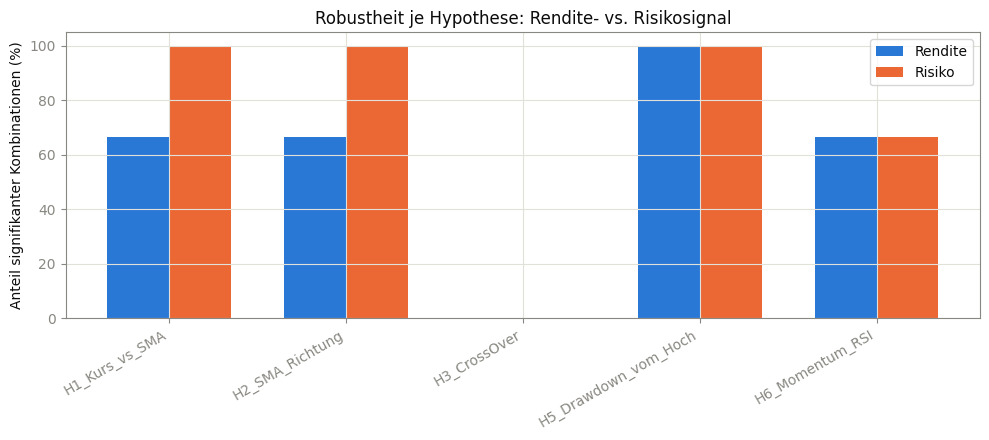

In [40]:
fig, achse = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(pivot_robustheit))
breite = 0.35
achse.bar(x - breite / 2, pivot_robustheit["Anteil signifikant (Rendite)"] * 100, breite, label="Rendite", color=COLOR_A)
achse.bar(x + breite / 2, pivot_robustheit["Anteil signifikant (Risiko)"] * 100, breite, label="Risiko", color=COLOR_B)
achse.set_xticks(x)
achse.set_xticklabels(pivot_robustheit.index, rotation=30, ha="right")
achse.set_ylabel("Anteil signifikanter Kombinationen (%)")
achse.legend()
plt.title("Robustheit je Hypothese: Rendite- vs. Risikosignal")
plt.tight_layout()
plt.show()


**Ergebnis:** Nur fünf der sechs Hypothesen liefern überhaupt testbare Ergebnisse – H4 (Divergenz) verfehlt sowohl für D1 als auch für D2 die Mindeststichprobe und taucht in der Übersicht daher nicht auf (siehe Abschnitt 4.4). Unter den verbleibenden fünf Hypothesen zeigt sich das aus den Einzelergebnissen bekannte Muster „Risiko robuster als Rendite“ nur bei H1 und H2: Bei beiden ist der Anteil signifikanter Ergebnisse beim Risiko (100 %) höher als bei der Rendite (67 %). H5 zeigt dagegen bei beiden Zielgrößen dieselbe hohe Robustheit (jeweils 100 %), H6 ebenfalls eine identische Quote (jeweils 67 %), und H3 liefert für keine der beiden Zielgrößen ein signifikantes Ergebnis (0 %).

**Praxisrelevanz für Börseninvestoren:** Die Übersicht zeigt, dass sich Risiko und Rendite nicht durchgängig unterschiedlich gut prognostizieren lassen, wie es ein pauschales „Risikosignale sind robuster“ nahelegen würde: H5 (Abstand vom Hoch) liefert ein durchgängig ebenso robustes Renditesignal wie ein Risikosignal. Für die Konstruktion eines Frühwarnsystems bedeutet dies, dass insbesondere die Drawdown-Stufe (H5) über die reine Risikoeinschätzung hinaus auch eine statistisch abgesicherte Renditeindikation liefert, während H1 und H2 primär als Risikoindikatoren zu verstehen sind.

## 5. Einordnung und Handlungsempfehlungen

| # | Hypothese | Eignung für ein Ampelsystem | Rolle |
|---|---|---|---|
| H1 | Kurs vs. SMA | Hoch (als Risikoindikator) | Stabile Basis, insbesondere SMA200 |
| H2 | SMA-Richtung | Hoch (als Risikoindikator) | Ergänzt H1; bei SMA20/SMA100 zusätzlich mit signifikantem Renditesignal |
| H3 | Cross-Over | Niedrig | Beide testbaren Paare ohne jede statistische Signifikanz |
| H4 | Divergenz | Niedrig | Weder D1 noch D2 statistisch testbar |
| H5 | Abstand vom Hoch | Hoch (Risiko- und Renditeindikator) | Parameterfreie Zusatzstufe mit durchgängiger Signifikanz bei beiden Zielgrößen |
| H6 | Momentum (RSI) | Niedrig bis mittel | Risikohinweis bei Extremwerten, kein Umkehrsignal |

**Zentraler Befund:** Bei H1 und H2 ist das Risikosignal robuster und häufiger statistisch abgesichert als das Renditesignal; bei kurzen und mittleren Zeitfenstern kehrt sich die Rendite-Beziehung teils sogar signifikant um (Mean-Reversion-Effekt). H5 (Abstand vom Hoch) sticht dabei hervor: Für den NASDAQ 100 sind sowohl das Risiko- als auch das Renditesignal in allen drei Horizonten durchgängig signifikant. Die Ausweitung auf Wochen- und Monatsbasis bei H3 zeigt zudem, dass längere Zeitbasen nicht automatisch aussagekräftigere Signale liefern, sondern vor allem die Ereignisanzahl reduzieren; bei H4 reicht die Ereignisanzahl selbst auf der kürzesten geprüften Zeitebene nicht für einen statistischen Test aus.

**Empfehlung:** Ein Ampelsystem sollte primär als **Risikoindikator** konzipiert werden, gestützt auf H1 und H2 (Trendposition und -richtung, mit SMA200 als stabiler Basis) sowie H5 (Drawdown-Status als objektive, parameterfreie Zusatzstufe, die zugleich das insgesamt robusteste Einzelsignal der Analyse liefert). H3, H4 und H6 liefern ergänzende, aber keine tragfähigen Kernbausteine.

## 6. Ampel-Systematik: Kategoriendefinition und Validierung

Die Einordnung in Abschnitt 5 identifiziert die Trendposition und -richtung
relativ zum SMA200 (H1, H2) sowie den Abstand vom bisherigen Hoch (H5) als
die robustesten Risikosignale der gesamten Analyse. Dieser Abschnitt leitet
daraus eine konkrete, dreistufige Ampel-Kategorisierung (Grün/Gelb/Rot) ab
und validiert sie mit derselben statistischen Methodik wie die
vorangegangenen Hypothesentests.

Bewusst nicht als Kernbaustein verwendet werden H3 (Cross-Over) und H4
(Divergenz): Beide liefern für die meisten geprüften Parametrisierungen zu
wenige Ereignisse für eine belastbare Kalibrierung (Abschnitt 4.3 und 4.4).
H6 (RSI) fließt als ergänzender Hinweis ein, wird aber nicht Teil der
Kernregel, da das zugehörige Risikosignal zwar vorhanden, aber weniger
konsistent abgesichert ist als bei H1, H2 und H5 (Abschnitt 4.7).


### 6.1 Bausteine: Trend-Score (H1 + H2) und Drawdown-Stufe (H5)

Aus H1 und H2 wird ein dreistufiger **Trend-Score** auf Basis des SMA200
gebildet, der beide Signale kombiniert:

- **0 Punkte:** Kurs notiert über dem SMA200 **und** dieser steigt
  gleichzeitig (eindeutig bullische Lage).
- **1 Punkt:** genau eine der beiden Bedingungen ist erfüllt (gemischte Lage).
- **2 Punkte:** Kurs notiert unter dem SMA200 **und** dieser fällt
  gleichzeitig (eindeutig bärische Lage).

Die bereits in Abschnitt 4.5 eingeführte **Drawdown-Stufe**
(`Drawdown_Bucket`) wird unverändert als zweiter Baustein übernommen.


In [41]:
def trend_score(kurs_über_sma: pd.Series, sma_steigend: pd.Series) -> pd.Series:
    # 0 = beide Bedingungen bullisch, 2 = beide bärisch, 1 = gemischt.
    # Tage ohne gültigen SMA200-Wert (Anfang der Zeitreihe) bleiben NaN.
    valide = kurs_über_sma.notna() & sma_steigend.notna()
    score = pd.Series(np.nan, index=df.index)
    score[valide & kurs_über_sma & sma_steigend] = 0
    score[valide & (kurs_über_sma != sma_steigend)] = 1
    score[valide & ~kurs_über_sma & ~sma_steigend] = 2
    return score


kurs_über_sma200 = df["Close"] > df["SMA200_d"]
sma200_steigend = df["SMA200_d"].diff() > 0
df["Trend_Score"] = trend_score(kurs_über_sma200, sma200_steigend)

print("Verteilung des Trend-Score (0 = bullisch, 2 = bärisch):")
print(df["Trend_Score"].value_counts().sort_index())


Verteilung des Trend-Score (0 = bullisch, 2 = bärisch):
Trend_Score
0.0000    3619
1.0000     443
2.0000     873
Name: count, dtype: int64


### 6.2 Empirische Grundlage der Kategoriengrenzen

Um die Zuordnung der zwölf Kombinationen aus Trend-Score (0 bis 2) und
Drawdown-Stufe (vier Stufen) zu den drei Ampelfarben nicht willkürlich zu
setzen, wird für jede Kombination der mittlere 90-Tage-Vorwärts-Drawdown
(`fwd_mdd_90d`) ausgewiesen – die Kennzahl, die laut Abschnitt 4.7 über
alle Hypothesen hinweg das robustere Signal liefert.


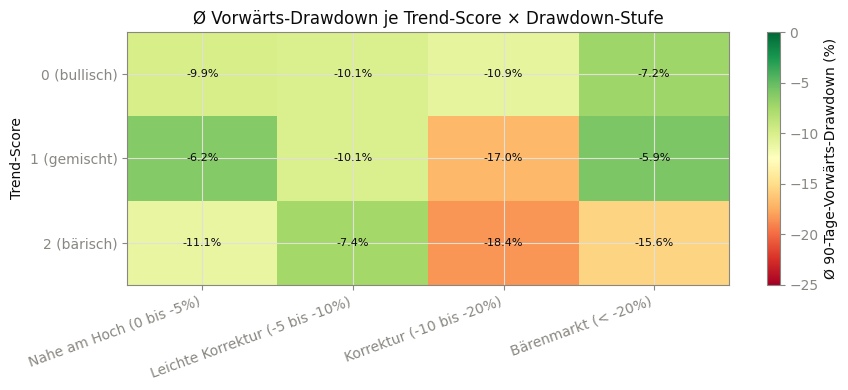

Drawdown_Bucket,Nahe am Hoch (0 bis -5%),Leichte Korrektur (-5 bis -10%),Korrektur (-10 bis -20%),Bärenmarkt (< -20%)
Trend_Score,,,,
0.0000,-0.0989,-0.1014,-0.1092,-0.0723
1.0000,-0.0618,-0.1014,-0.1698,-0.0587
2.0000,-0.1109,-0.0744,-0.1841,-0.1559


In [42]:
heatmap_basis = df.groupby(["Trend_Score", "Drawdown_Bucket"])["fwd_mdd_90d"].mean().unstack()
heatmap_basis = heatmap_basis[bucket_reihenfolge]

fig, achse = plt.subplots(figsize=(9, 4))
bild = achse.imshow(heatmap_basis.values * 100, cmap="RdYlGn", aspect="auto", vmin=-25, vmax=0)
achse.set_xticks(range(len(bucket_reihenfolge)))
achse.set_xticklabels(bucket_reihenfolge, rotation=20, ha="right")
achse.set_yticks(range(3))
achse.set_yticklabels(["0 (bullisch)", "1 (gemischt)", "2 (bärisch)"])
achse.set_ylabel("Trend-Score")
for i in range(heatmap_basis.shape[0]):
    for j in range(heatmap_basis.shape[1]):
        wert = heatmap_basis.values[i, j]
        if not np.isnan(wert):
            achse.text(j, i, f"{wert * 100:.1f}%", ha="center", va="center", fontsize=8)
fig.colorbar(bild, ax=achse, label="Ø 90-Tage-Vorwärts-Drawdown (%)")
plt.title("Ø Vorwärts-Drawdown je Trend-Score × Drawdown-Stufe")
plt.tight_layout()
plt.show()
heatmap_basis


**Ergebnis:** Die Heatmap zeigt für den NASDAQ 100 ein weniger geradliniges Muster als eine einfache Diagonalstruktur vermuten ließe: Am ausgeprägtesten ist das Risiko in den Zellen Trend-Score 2 × Korrektur (−18,4 %) und Trend-Score 1 × Korrektur (−17,0 %) – beide deutlich höher als in jeder anderen Kombination –, während Trend-Score 2 × Bärenmarkt mit −15,6 % knapp darunter liegt. Am günstigsten schneiden Trend-Score 1 × Bärenmarkt (−5,9 %) und Trend-Score 0 × Bärenmarkt (−7,2 %) ab, vermutlich ein Erholungseffekt nach besonders tiefen Rückgängen – ein Muster, das angesichts der kleinen Stichprobe dieser Zellen mit Vorsicht zu interpretieren ist (Trend-Score 1 umfasst nur 443 der 4.930 Handelstage, verteilt über vier Drawdown-Stufen). Die Zellen Trend-Score 0 × „Nahe am Hoch“/„Leichte Korrektur“ (rund −9,9 % bzw. −10,1 %) liegen im Mittelfeld – deutlich unter den beiden ausgeprägtesten Risikozellen, aber nicht am absoluten Minimum der Tabelle.

Trotz dieser zellenweisen Unregelmäßigkeiten, die angesichts teils kleiner Stichproben einzelner Kombinationen zu erwarten sind, bestätigt die in Abschnitt 6.4 durchgeführte aggregierte Validierung der drei resultierenden Ampelfarben eine überwiegend signifikante Risikotrennung (siehe dort). Die Regel „beide Bausteine übereinstimmend günstig = Grün, beide übereinstimmend ungünstig = Rot“ wird damit nicht durch eine perfekt monotone Heatmap, sondern durch die nachgelagerte Gruppenvalidierung gestützt.

### 6.3 Kategorienregel

Auf Basis der Heatmap in 6.2 werden die zwölf Kombinationen den drei
Ampelfarben zugeordnet: **Grün**, wenn Trend-Score und Drawdown-Stufe
übereinstimmend ein günstiges Bild zeichnen; **Rot**, wenn beide
übereinstimmend ein ungünstiges Bild zeichnen; **Gelb** für alle gemischten
Fälle dazwischen. Diese Regel überträgt damit unmittelbar das in Abschnitt
4.7 dokumentierte Muster auf die Kategorienbildung: Risikosignale sind bei
H1, H2 und H5 am robustesten abgesichert, wenn sie übereinstimmend in
dieselbe Richtung weisen.


In [43]:
def ampel_farbe(trend_score: float, drawdown_bucket: str) -> str:
    bullisch = trend_score == 0
    bärisch = trend_score == 2
    tief = drawdown_bucket in ("Korrektur (-10 bis -20%)", "Bärenmarkt (< -20%)")
    flach = drawdown_bucket in ("Nahe am Hoch (0 bis -5%)", "Leichte Korrektur (-5 bis -10%)")

    if bullisch and flach:
        return "Grün"
    if bärisch and tief:
        return "Rot"
    return "Gelb"


df["Ampel"] = [
    ampel_farbe(ts, db) if pd.notna(ts) else np.nan
    for ts, db in zip(df["Trend_Score"], df["Drawdown_Bucket"])
]

print("Verteilung der Handelstage auf die drei Ampelfarben:")
print(df["Ampel"].value_counts().reindex(["Grün", "Gelb", "Rot"]))


Verteilung der Handelstage auf die drei Ampelfarben:


Ampel
Grün    3199
Gelb    1134
Rot      602
Name: count, dtype: int64


### 6.4 Statistische Validierung der Ampelfarben

Analog zu den Hypothesentests in Abschnitt 4 werden die drei Ampelfarben
paarweise mit `vergleiche_gruppen()` auf Vorwärtsrendite und -drawdown
verglichen.


In [44]:
ampel_farben = ["Grün", "Gelb", "Rot"]
ampel_paare = [("Grün", "Gelb"), ("Gelb", "Rot"), ("Grün", "Rot")]

ergebnisse_ampel = []
for a, b in ampel_paare:
    maske_a = df["Ampel"] == a
    maske_b = df["Ampel"] == b
    for h in HORIZONS:
        for ziel in ["fwd_return", "fwd_mdd"]:
            res = vergleiche_gruppen(
                df.loc[maske_a, f"{ziel}_{h}d"], df.loc[maske_b, f"{ziel}_{h}d"],
                label_a=a, label_b=b,
            )
            if res:
                res.update({"vergleich": f"{a} vs. {b}", "horizont_tage": h, "zielgröße": ziel})
                ergebnisse_ampel.append(res)

tabelle_ampel = ergebnisse_zu_tabelle(ergebnisse_ampel)
tabelle_ampel[["vergleich", "horizont_tage", "zielgröße", "mean_a", "mean_b", "t_pvalue", "u_pvalue", "signifikant_5pct"]]


,vergleich,horizont_tage,zielgröße,mean_a,mean_b,t_pvalue,u_pvalue,signifikant_5pct
0,Grün vs. Gelb,30,fwd_return,0.0148,0.0339,0.0000,0.0000,True
1,Grün vs. Gelb,30,fwd_mdd,-0.0537,-0.0594,0.0001,0.0000,True
2,Grün vs. Gelb,60,fwd_return,0.0324,0.0658,0.0000,0.0000,True
3,Grün vs. Gelb,60,fwd_mdd,-0.0797,-0.0827,0.1091,0.0152,False
4,Grün vs. Gelb,90,fwd_return,0.0523,0.0866,0.0000,0.0000,True
5,Grün vs. Gelb,90,fwd_mdd,-0.0993,-0.1039,0.0491,0.1890,False
6,Gelb vs. Rot,30,fwd_return,0.0339,0.0167,0.0004,0.0170,True
7,Gelb vs. Rot,30,fwd_mdd,-0.0594,-0.1022,0.0000,0.0000,True
8,Gelb vs. Rot,60,fwd_return,0.0658,0.0276,0.0000,0.0000,True
9,Gelb vs. Rot,60,fwd_mdd,-0.0827,-0.1434,0.0000,0.0000,True


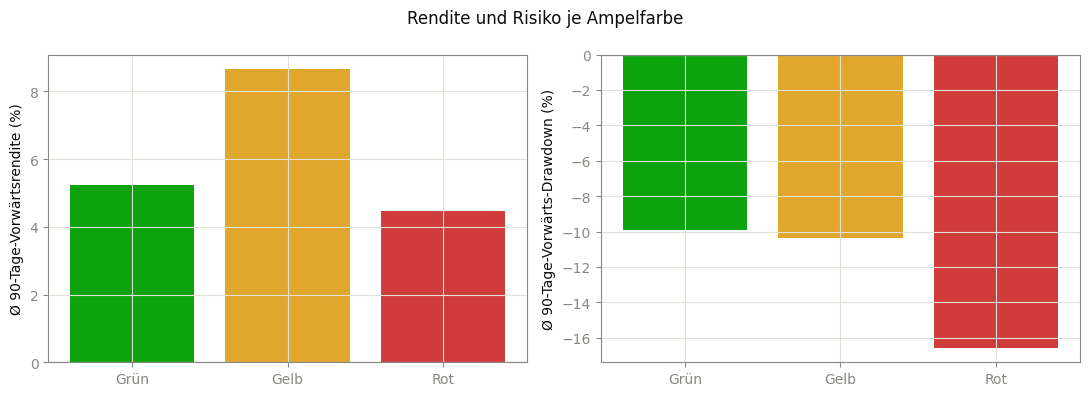

In [45]:
mittelwerte_ampel = df.groupby("Ampel")[["fwd_return_90d", "fwd_mdd_90d"]].mean().reindex(ampel_farben)
ampel_farbcodes = {"Grün": COLOR_GOOD, "Gelb": COLOR_WARN, "Rot": COLOR_BAD}

fig, achsen = plt.subplots(1, 2, figsize=(11, 4))
for achse, spalte, titel in zip(achsen, ["fwd_return_90d", "fwd_mdd_90d"],
                                 ["Ø 90-Tage-Vorwärtsrendite", "Ø 90-Tage-Vorwärts-Drawdown"]):
    achse.bar(mittelwerte_ampel.index, mittelwerte_ampel[spalte] * 100,
              color=[ampel_farbcodes[f] for f in mittelwerte_ampel.index])
    achse.axhline(0, color=COLOR_MUTED, linewidth=0.8)
    achse.set_ylabel(f"{titel} (%)")
fig.suptitle("Rendite und Risiko je Ampelfarbe")
fig.tight_layout()
plt.show()


**Ergebnis:** Die drei Ampelfarben trennen das Risiko überwiegend, aber nicht bei jedem Farbpaar und Horizont signifikant: Der mittlere Vorwärts-Drawdown steigt von Grün (−5,4 % / −8,0 % / −9,9 % über 30/60/90 Tage) über Gelb (−5,9 % / −8,3 % / −10,4 %) zu Rot (−10,2 % / −14,3 % / −16,5 %) an. Sieben der neun Risikovergleiche (drei Farbpaare × drei Horizonte) sind statistisch signifikant; nicht signifikant ist ausschließlich der Unterschied zwischen Grün und Gelb bei 60 und 90 Tagen, wo beide Farben nah beieinanderliegen. Bei der Rendite zeigt sich ein auffälliges, nicht-monotones Muster: Gelb weist in allen drei Horizonten die höchste mittlere Rendite auf (90 Tage: 8,6 %), signifikant höher als sowohl Grün (5,2 %) als auch Rot (4,5 %); zwischen Grün und Rot selbst ist dagegen in keinem Horizont ein signifikanter Renditeunterschied nachweisbar.

**Praxisrelevanz für Börseninvestoren:** Die Ampel funktioniert klar als Risikoindikator – insbesondere die Abgrenzung von Rot gegenüber Grün und Gelb ist in allen Horizonten hochsignifikant. Für die Rendite liefert die Ampel dagegen kein einfaches „Grün ist besser als Rot“-Bild: Die Gelb-Phase (gemischte Trend-/Drawdown-Lage) war historisch mit der höchsten erwarteten Rendite verbunden, während sich Grün und Rot in ihrer Renditeerwartung kaum unterscheiden. Für Investoren bedeutet dies, dass die Ampel primär zur Risikosteuerung eingesetzt werden sollte; eine Interpretation von Grün als „renditestärkste“ Phase ist durch die Daten nicht gedeckt.

### 6.5 Ergänzende Rolle von H6 (RSI)

Der RSI wird nicht in die Kernregel aufgenommen, da das zugehörige Risikosignal in Abschnitt 4.6 zwar in zwei der drei Horizonte (30 und 60 Tage) signifikant ist, jedoch schwächer und weniger durchgängig abgesichert ist als bei H1, H2 und H5, und zudem eine kontraintuitive Richtung aufweist: Überverkaufte Phasen (RSI < 30) trugen historisch das höhere Risiko, nicht überkaufte Phasen. Für die Praxis bedeutet dies, dass ein stark überverkaufter RSI innerhalb einer Gelb-Phase als zusätzlicher Hinweis auf eine mögliche Verschärfung Richtung Rot gelesen werden kann, ohne dass der RSI allein eine Kategorie bestimmt.

### 6.6 Ampel-Hintergrund im Kursverlauf

Die folgende Darstellung überträgt die Kategorienregel auf den gesamten
Analysezeitraum und macht sichtbar, wie sich Grün-, Gelb- und Rot-Phasen im
historischen Kursverlauf verteilen. Abschnitt 7 untersucht anschließend,
welche Rendite- und Risikowirkung ein Ausschluss der Rot-Phasen gehabt
hätte.


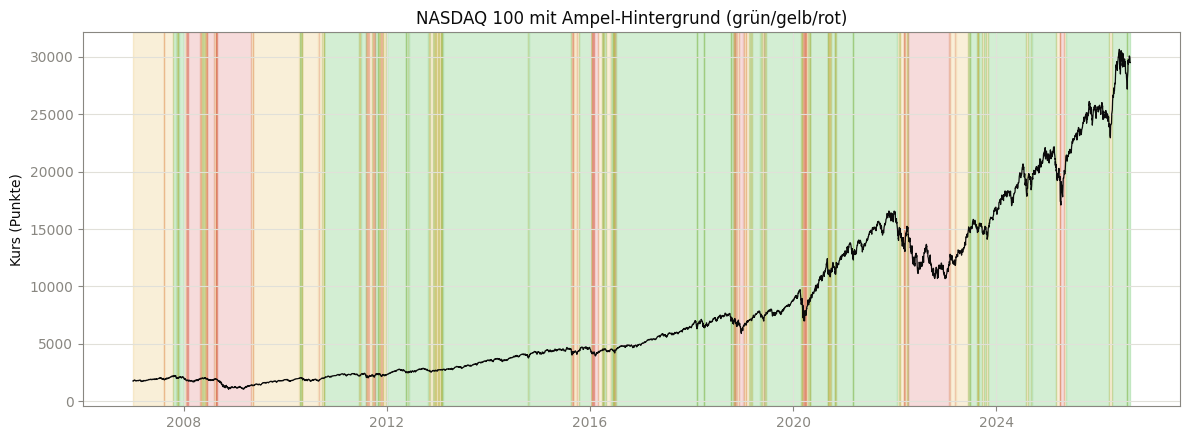

In [46]:
fig, achse = plt.subplots(figsize=(12, 4.5))
for farbe in ampel_farben:
    maske = df["Ampel"] == farbe
    achse.fill_between(df.index, 0, 1, where=maske, color=ampel_farbcodes[farbe], alpha=0.18,
                        transform=achse.get_xaxis_transform())
achse.plot(df.index, df["Close"], color=COLOR_PRICE, linewidth=0.9)
achse.set_ylabel("Kurs (Punkte)")
achse.set_title("NASDAQ 100 mit Ampel-Hintergrund (grün/gelb/rot)")
fig.tight_layout()
plt.show()


## 7. Was-wäre-wenn-Analyse: Wirkung des Risikophasen-Ausschlusses

Die Hypothesentests in Abschnitt 4 verwenden vorwärtsgerichtete Zielgrößen (`fwd_return`, `fwd_mdd`) ausschließlich zur Signifikanzprüfung – sie beantworten, ob ein Regimezustand statistisch mit einer anderen Folgeperiode einhergeht, nicht, was ein regelbasiertes Investment ergeben hätte. Dieser Abschnitt nimmt die zweite Perspektive ein: Für jede Hypothese, bei der sich ein anhaltender Regimezustand definieren lässt, wird simuliert, wie sich Gesamtrendite, annualisierte Rendite (CAGR) und maximaler Drawdown verändert hätten, wenn an Tagen mit dem jeweils ungünstigeren Regimezustand nicht investiert gewesen wäre.

**Methodische Abgrenzung:** Anders als die Vorwärtsgrößen in Abschnitt 4 verwendet diese Analyse ausschließlich den zum jeweiligen Zeitpunkt bereits bekannten Regimezustand (z. B. „Kurs notiert heute unter dem SMA200“) und keine zukünftigen Informationen – die Simulation ist damit frei von Rückschaufehlern (Look-ahead-Bias) im Sinne einer nachvollziehbaren Handelsregel. Vereinfachend werden Transaktionskosten und eine Verzinsung der Cash-Position an ausgeschlossenen Tagen nicht berücksichtigt.

**H4 (Divergenz) wird bewusst ausgeschlossen:** D1 und D2 sind seltene Punktereignisse (9 bzw. 2 Fälle seit 2007, beide unterhalb der Mindeststichprobe für einen Signifikanztest) ohne anhaltenden Regimezustand – daraus lässt sich keine Phase ableiten, die über einen längeren Zeitraum „ausgeschlossen“ werden könnte.

### 7.1 Backtest-Hilfsfunktionen


In [47]:
def historischer_max_drawdown(werte: pd.Series) -> float:
    # Klassischer Peak-to-Trough-Drawdown einer (kumulierten) Wertreihe -
    # im Unterschied zu forward_max_drawdown rückblickend über die gesamte Reihe.
    laufendes_hoch = werte.cummax()
    return (werte / laufendes_hoch - 1).min()


def was_wäre_wenn(schlecht: pd.Series, label: str) -> dict:
    # Simuliert eine Strategie, die an "schlecht" markierten Tagen in Cash
    # geht (Tagesrendite 0, ohne Cash-Verzinsung und Transaktionskosten) und
    # ansonsten voll investiert ist - und vergleicht das Ergebnis mit Buy & Hold.
    tagesrendite = df["Close"].pct_change().fillna(0)
    schlecht_bereinigt = schlecht.reindex(df.index).fillna(False)

    strategie_rendite = tagesrendite.where(~schlecht_bereinigt, 0)
    equity_buy_hold = (1 + tagesrendite).cumprod()
    equity_strategie = (1 + strategie_rendite).cumprod()

    jahre = (df.index[-1] - df.index[0]).days / 365.25

    def kennzahlen(equity: pd.Series) -> tuple[float, float, float]:
        gesamtrendite = equity.iloc[-1] - 1
        cagr = equity.iloc[-1] ** (1 / jahre) - 1
        mdd = historischer_max_drawdown(equity)
        return gesamtrendite, cagr, mdd

    gr_bh, cagr_bh, mdd_bh = kennzahlen(equity_buy_hold)
    gr_st, cagr_st, mdd_st = kennzahlen(equity_strategie)

    return {
        "hypothese": label,
        "anteil_schlecht_tage": schlecht_bereinigt.mean(),
        "gesamtrendite_buy_hold": gr_bh, "cagr_buy_hold": cagr_bh, "max_drawdown_buy_hold": mdd_bh,
        "gesamtrendite_strategie": gr_st, "cagr_strategie": cagr_st, "max_drawdown_strategie": mdd_st,
        "equity_buy_hold": equity_buy_hold, "equity_strategie": equity_strategie,
    }


print("Backtest-Hilfsfunktionen definiert.")


Backtest-Hilfsfunktionen definiert.


### 7.2 Regime-Definitionen je Hypothese

Für jede einbezogene Hypothese wird der „schlechte" (auszuschließende)
Regimezustand aus den bereits berechneten Spalten abgeleitet:

- **H1** (SMA20/100/200): Kurs notiert unter dem jeweiligen SMA.
- **H2** (SMA20/100/200): der jeweilige SMA fällt.
- **H3** (nur die beiden testbaren Tagesbasis-Paare SMA20/100 und
  SMA20/200): Regime zwischen Golden und Death Cross, durch Fortschreibung
  der Kreuzungsereignisse gebildet; „schlecht" = Zustand seit dem letzten
  Death Cross.
- **H5**: Drawdown-Stufe „Korrektur" oder „Bärenmarkt" (mindestens 10 %
  unter dem bisherigen Hoch).
- **H6**: RSI < 30 (überverkauft) – bewusst nicht die klassische
  „RSI > 70 = riskant"-Lesart, da Abschnitt 4.6 zeigt, dass überverkaufte
  Phasen historisch das höhere Risiko trugen.
- **Kombinierte Ampel** (Abschnitt 6): Rot-Tage.


In [48]:
def crossover_regime_schlecht(golden: pd.Series, death: pd.Series) -> pd.Series:
    # Bildet einen anhaltenden Regimezustand aus den punktuellen Kreuzungs-
    # ereignissen: "schlecht" gilt ab einem Death Cross, bis der nächste
    # Golden Cross eintritt (Fortschreibung per ffill).
    ereignis = pd.Series(np.nan, index=df.index, dtype="object")
    ereignis[golden] = False
    ereignis[death] = True
    return ereignis.ffill().fillna(False).astype(bool)


regime_definitionen: dict[str, pd.Series] = {}

for w in SMA_WINDOWS_DAILY:
    über, _ = regime_gruppen(w)
    regime_definitionen[f"H1_SMA{w}"] = ~über.reindex(df.index).fillna(False)

for w in SMA_WINDOWS_DAILY:
    steigend, _ = regime_gruppen_richtung(w)
    regime_definitionen[f"H2_SMA{w}"] = ~steigend.reindex(df.index).fillna(False)

for kurz, lang in [(20, 100), (20, 200)]:
    golden, death = finde_crossover(df[f"SMA{kurz}_d"], df[f"SMA{lang}_d"])
    regime_definitionen[f"H3_SMA{kurz}_{lang}"] = crossover_regime_schlecht(golden, death)

regime_definitionen["H5_Drawdown"] = df["Drawdown_Bucket"].isin(
    ["Korrektur (-10 bis -20%)", "Bärenmarkt (< -20%)"]
)
regime_definitionen["H6_RSI_überverkauft"] = df["RSI14"] < 30
regime_definitionen["Ampel_Rot"] = df["Ampel"] == "Rot"

print("Regime-Definitionen für die Was-wäre-wenn-Analyse:", list(regime_definitionen.keys()))


Regime-Definitionen für die Was-wäre-wenn-Analyse: ['H1_SMA20', 'H1_SMA100', 'H1_SMA200', 'H2_SMA20', 'H2_SMA100', 'H2_SMA200', 'H3_SMA20_100', 'H3_SMA20_200', 'H5_Drawdown', 'H6_RSI_überverkauft', 'Ampel_Rot']


### 7.3 Konsolidierte Kennzahlenübersicht

Für alle elf Parametrisierungen werden Gesamtrendite, CAGR und maximaler
Drawdown von Buy & Hold der jeweiligen Ausschluss-Strategie
gegenübergestellt.


In [49]:
ergebnisse_www = [was_wäre_wenn(schlecht, name) for name, schlecht in regime_definitionen.items()]
tabelle_was_wäre_wenn = pd.DataFrame(ergebnisse_www).drop(columns=["equity_buy_hold", "equity_strategie"])
tabelle_was_wäre_wenn


,hypothese,anteil_schlecht_tage,gesamtrendite_buy_hold,cagr_buy_hold,max_drawdown_buy_hold,gesamtrendite_strategie,cagr_strategie,max_drawdown_strategie
0,H1_SMA20,0.3508,15.7668,0.1545,-0.5371,"35,170.7526",0.7047,-0.0698
1,H1_SMA100,0.2642,15.7668,0.1545,-0.5371,253.1093,0.3260,-0.1278
2,H1_SMA200,0.2359,15.7668,0.1545,-0.5371,68.2999,0.2411,-0.1358
3,H2_SMA20,0.3467,15.7668,0.1545,-0.5371,953.3547,0.4185,-0.0915
4,H2_SMA100,0.2355,15.7668,0.1545,-0.5371,52.0739,0.2243,-0.2174
5,H2_SMA200,0.2077,15.7668,0.1545,-0.5371,51.5471,0.2237,-0.1849
6,H3_SMA20_100,0.2349,15.7668,0.1545,-0.5371,8.6255,0.1223,-0.2599
7,H3_SMA20_200,0.2012,15.7668,0.1545,-0.5371,7.3558,0.1142,-0.3166
8,H5_Drawdown,0.2600,15.7668,0.1545,-0.5371,97.0152,0.2632,-0.0989
9,H6_RSI_überverkauft,0.0111,15.7668,0.1545,-0.5371,62.3286,0.2354,-0.3044


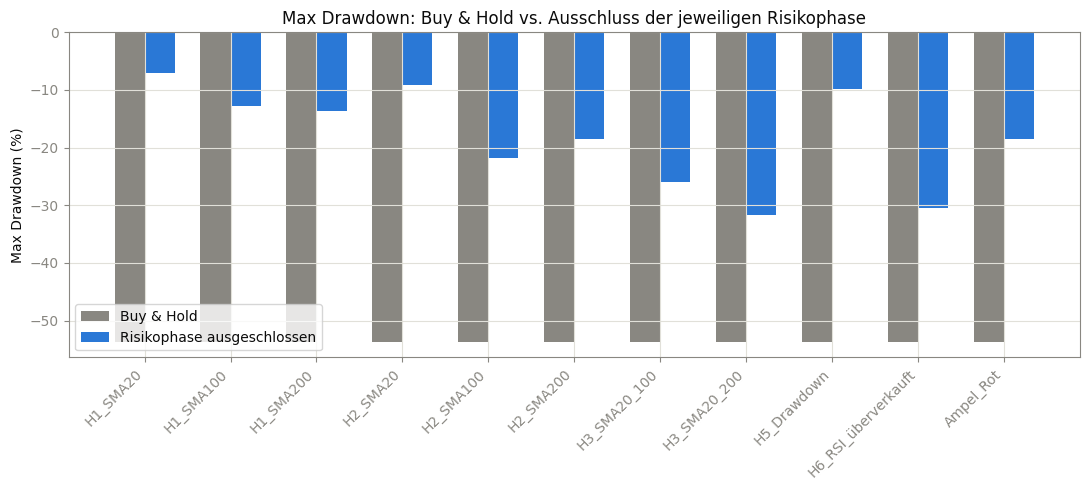

In [50]:
fig, achse = plt.subplots(figsize=(11, 5))
x = np.arange(len(tabelle_was_wäre_wenn))
breite = 0.35
achse.bar(x - breite / 2, tabelle_was_wäre_wenn["max_drawdown_buy_hold"] * 100, breite,
          label="Buy & Hold", color=COLOR_MUTED)
achse.bar(x + breite / 2, tabelle_was_wäre_wenn["max_drawdown_strategie"] * 100, breite,
          label="Risikophase ausgeschlossen", color=COLOR_A)
achse.set_xticks(x)
achse.set_xticklabels(tabelle_was_wäre_wenn["hypothese"], rotation=45, ha="right")
achse.set_ylabel("Max Drawdown (%)")
achse.legend()
plt.title("Max Drawdown: Buy & Hold vs. Ausschluss der jeweiligen Risikophase")
plt.tight_layout()
plt.show()


**Ergebnis:** Über alle elf Parametrisierungen hinweg reduziert der Ausschluss der jeweils definierten Risikophase den Max Drawdown gegenüber Buy & Hold (−53,7 %) durchgängig – in den meisten Fällen auf einen Bereich von rund −7 % bis −22 %. Zwei Ausnahmen bestätigen den in Abschnitt 4.3 dokumentierten Befund: Bei den beiden Cross-Over-Paaren (H3) bleibt der Max Drawdown mit −26,0 % (SMA20/100) bzw. −31,7 % (SMA20/200) deutlich höher als bei den übrigen Hypothesen, und die annualisierte Rendite liegt mit 12,3 % bzw. 11,5 % sogar unter der Buy-&-Hold-CAGR von 15,5 % – ein Ausschluss auf Basis eines nicht signifikanten Signals (siehe 4.3) verschlechtert hier tendenziell das Chance-Risiko-Verhältnis, statt es zu verbessern. Am auffälligsten ist erneut H6 (RSI < 30): Der Ausschluss von nur 1,1 % der Handelstage senkt den Max Drawdown bereits von −53,7 % auf −30,4 % und erhöht die CAGR auf 23,6 % – ein Beleg dafür, dass sich extreme Überverkauft-Phasen zeitlich eng mit den größten Kurseinbrüchen überschneiden. Am oberen Ende steht H1/SMA20: Der Ausschluss von 35,2 % der Handelstage senkt den Max Drawdown auf −7,0 % und liefert rechnerisch eine CAGR von 70,8 % – ein durch die lange Historie (rund 19,5 Jahre) extrem verstärkter Zinseszinseffekt, der weit außerhalb dessen liegt, was ein handelbares Signal realistisch leisten kann (siehe methodische Abgrenzung).

**Praxisrelevanz für Börseninvestoren:** Die stärksten CAGR-Verbesserungen zeigen sich bei den schnellsten Parametrisierungen (H1/H2 mit SMA20), die allein aufgrund ihrer hohen Reaktionsgeschwindigkeit einen großen Anteil der Verlusttage vermeiden. Da die Simulation weder Transaktionskosten noch Slippage berücksichtigt (siehe methodische Abgrenzung zu Beginn von Abschnitt 7) und ein SMA20-Signal in der Praxis sehr häufig wechselt, sind diese Ergebnisse – allen voran die CAGR von über 70 % bei H1/SMA20 – mit erheblicher Vorsicht zu interpretieren: Sie zeigen das theoretische Potenzial einer regelbasierten Risikosteuerung, nicht die realistisch erzielbare Rendite einer handelbaren Strategie. Die trägeren, robusteren Parametrisierungen (SMA200, Drawdown-Stufe, kombinierte Ampel) liefern mit CAGR-Werten zwischen rund 22 % und 26 % bei gleichzeitig deutlich reduziertem Max Drawdown (rund −9 % bis −18 %) ein realistischeres Bild des Nutzens einer Ampel-gestützten Risikosteuerung.

### 7.4 Vertiefte Einzelbetrachtung

Für sechs repräsentative Fälle wird zusätzlich der zeitliche Verlauf
dargestellt: oben der Kursverlauf mit rot hinterlegter Ausschlussphase,
darunter die Wertentwicklung von Buy & Hold gegenüber der
Ausschluss-Strategie (logarithmische Skala, Startwert = 1).


In [51]:
def plotte_was_wäre_wenn(name: str, schlecht: pd.Series, titel: str) -> dict:
    ergebnis = was_wäre_wenn(schlecht, name)
    schlecht_reindiziert = schlecht.reindex(df.index).fillna(False)

    fig, (achse_kurs, achse_equity) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

    achse_kurs.fill_between(df.index, 0, 1, where=schlecht_reindiziert, color=COLOR_BAD, alpha=0.15,
                             transform=achse_kurs.get_xaxis_transform())
    achse_kurs.plot(df.index, df["Close"], color=COLOR_PRICE, linewidth=0.9)
    achse_kurs.set_ylabel("Kurs (Punkte)")
    achse_kurs.set_title(f"{titel} – rot hinterlegt: ausgeschlossene Risikophase")

    achse_equity.plot(df.index, ergebnis["equity_buy_hold"], color=COLOR_MUTED, label="Buy & Hold")
    achse_equity.plot(df.index, ergebnis["equity_strategie"], color=COLOR_A, label="Risikophase ausgeschlossen")
    achse_equity.set_yscale("log")
    achse_equity.set_ylabel("Wertentwicklung (Start = 1, log. Skala)")
    achse_equity.legend()

    fig.tight_layout()
    plt.show()

    print(f"Anteil ausgeschlossener Handelstage: {ergebnis['anteil_schlecht_tage']:.1%}")
    print(f"Gesamtrendite  - Buy & Hold: {ergebnis['gesamtrendite_buy_hold']:.1%} | Ausschluss: {ergebnis['gesamtrendite_strategie']:.1%}")
    print(f"CAGR           - Buy & Hold: {ergebnis['cagr_buy_hold']:.1%} | Ausschluss: {ergebnis['cagr_strategie']:.1%}")
    print(f"Max Drawdown   - Buy & Hold: {ergebnis['max_drawdown_buy_hold']:.1%} | Ausschluss: {ergebnis['max_drawdown_strategie']:.1%}")
    return ergebnis


#### H1 – Kurs unter SMA200 ausgeschlossen


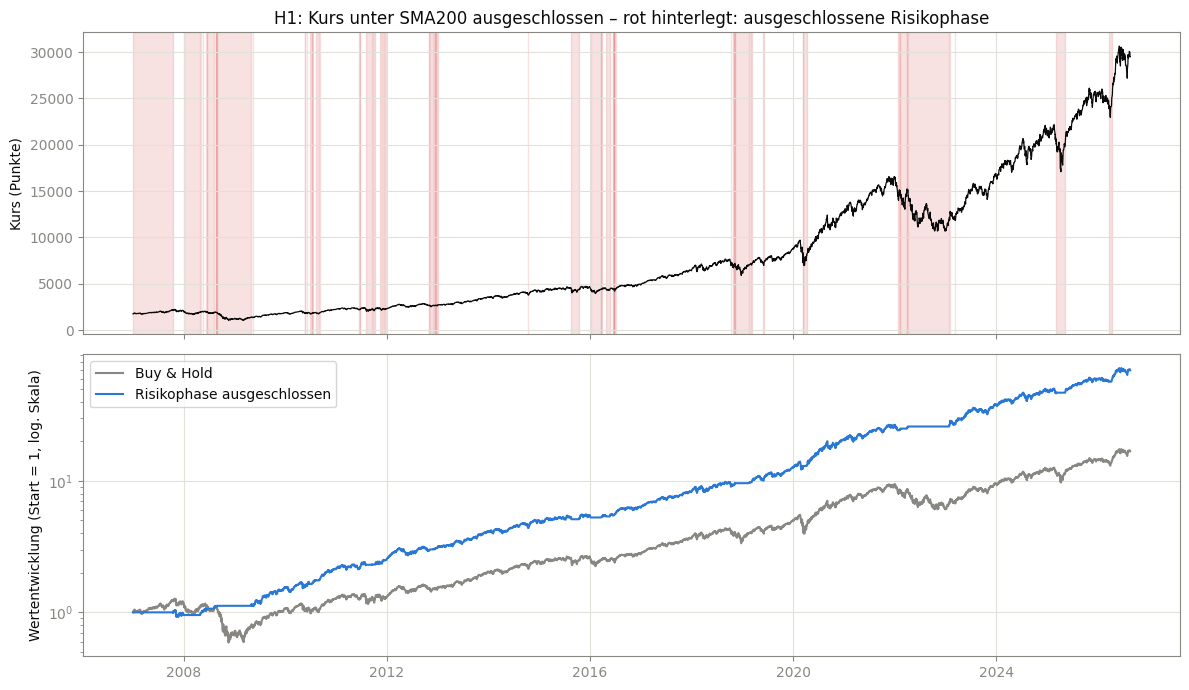

Anteil ausgeschlossener Handelstage: 23.6%
Gesamtrendite  - Buy & Hold: 1576.7% | Ausschluss: 6830.0%
CAGR           - Buy & Hold: 15.4% | Ausschluss: 24.1%
Max Drawdown   - Buy & Hold: -53.7% | Ausschluss: -13.6%


In [52]:
_ = plotte_was_wäre_wenn("H1_SMA200", regime_definitionen["H1_SMA200"], "H1: Kurs unter SMA200 ausgeschlossen")


**Ergebnis:** Der Ausschluss der 23,6 % Handelstage, an denen der Kurs unter dem SMA200 notiert, senkt den Max Drawdown von −53,7 % (Buy & Hold) auf −13,6 % und erhöht die CAGR von 15,5 % auf 24,2 %. Dies bestätigt quantitativ, warum H1/SMA200 in den Abschnitten 4.1 und 5 als robustester Kernbaustein der Ampel identifiziert wurde.

**Praxisrelevanz für Börseninvestoren:** Das obere Diagramm zeigt, dass sich die rot hinterlegten Phasen mit den bereits in Abschnitt 4.1 dokumentierten längeren Bärenmarktphasen decken. Ein Investor, der ausschließlich bei Kurs über SMA200 investiert gewesen wäre, hätte historisch einen erheblichen Teil des maximalen Verlusts vermieden – allerdings ohne Berücksichtigung von Transaktionskosten und mit dem Risiko einzelner Fehlsignale bei kurzen Regimewechseln (siehe Regime-Laufzeiten in Abschnitt 4.1, mediane Phasendauer von nur 3 Handelstagen in beiden Zuständen).

#### H2 – Fallende SMA200-Richtung ausgeschlossen


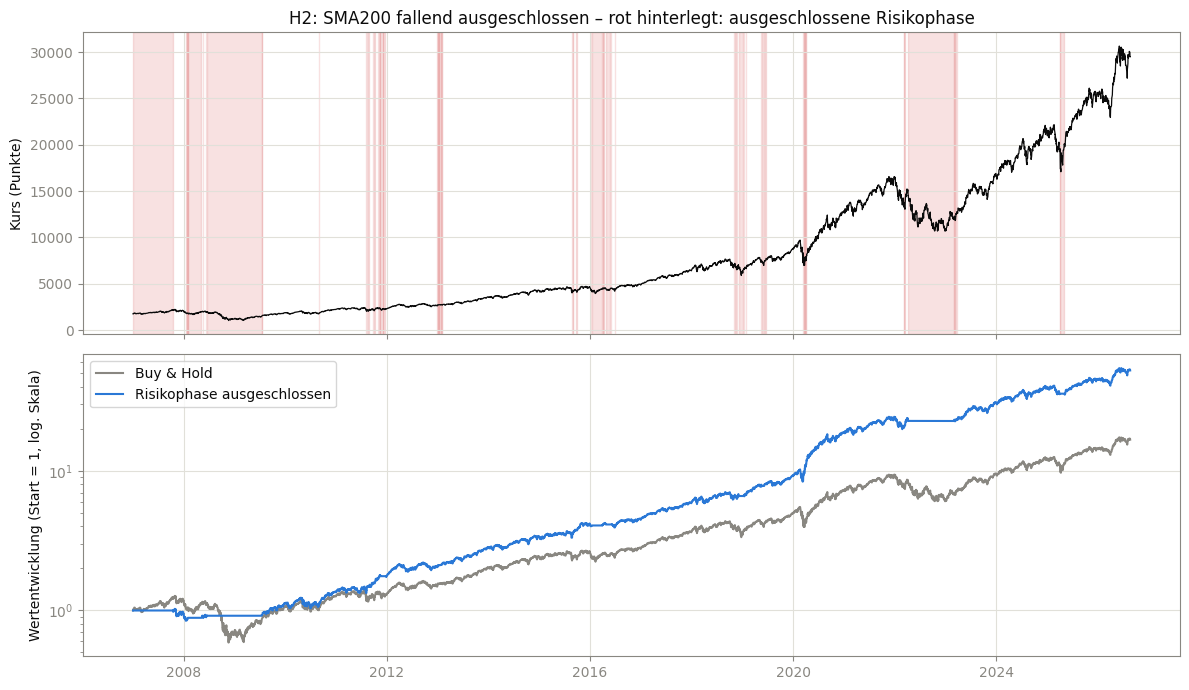

Anteil ausgeschlossener Handelstage: 20.8%
Gesamtrendite  - Buy & Hold: 1576.7% | Ausschluss: 5154.7%
CAGR           - Buy & Hold: 15.4% | Ausschluss: 22.4%
Max Drawdown   - Buy & Hold: -53.7% | Ausschluss: -18.5%


In [53]:
_ = plotte_was_wäre_wenn("H2_SMA200", regime_definitionen["H2_SMA200"], "H2: SMA200 fallend ausgeschlossen")


**Ergebnis:** Der Ausschluss der 20,8 % Handelstage mit fallendem SMA200 senkt den Max Drawdown von −53,7 % auf −18,5 % und erhöht die CAGR von 15,5 % auf 22,5 % – eine spürbare, wenn auch etwas schwächere Verbesserung als bei H1/SMA200.

**Praxisrelevanz für Börseninvestoren:** Da SMA200-Position (H1) und -Richtung (H2) laut Abschnitt 6.1 eng zusammenhängen, überrascht die ähnliche Grundtendenz nicht; die etwas geringere Verbesserung bei H2 spiegelt wider, dass die Richtung träger auf Trendwenden reagiert als die reine Positionsfrage.

#### H3 – Death-Cross-Regime (SMA20/200) ausgeschlossen


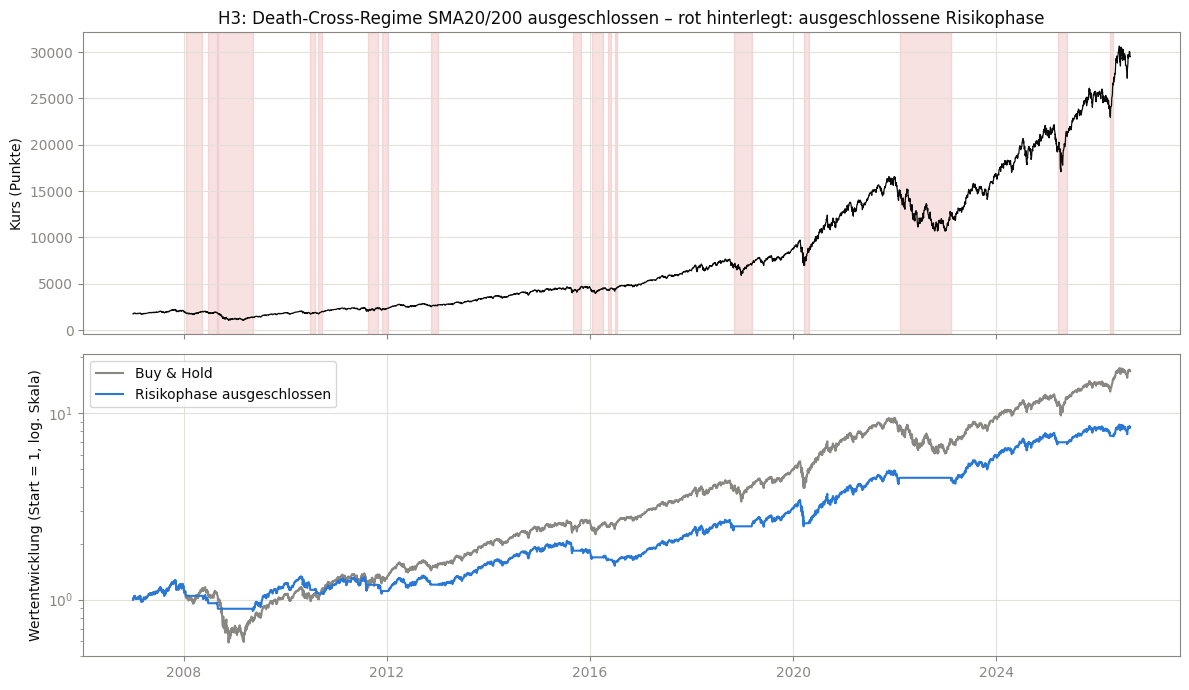

Anteil ausgeschlossener Handelstage: 20.1%
Gesamtrendite  - Buy & Hold: 1576.7% | Ausschluss: 735.6%
CAGR           - Buy & Hold: 15.4% | Ausschluss: 11.4%
Max Drawdown   - Buy & Hold: -53.7% | Ausschluss: -31.7%


In [54]:
_ = plotte_was_wäre_wenn("H3_SMA20_200", regime_definitionen["H3_SMA20_200"], "H3: Death-Cross-Regime SMA20/200 ausgeschlossen")


**Ergebnis:** Der Ausschluss der 20,1 % Handelstage im Death-Cross-Regime (SMA20/200) senkt den Max Drawdown von −53,7 % auf −31,7 %, reduziert aber gleichzeitig die CAGR von 15,5 % auf 11,5 %.

**Praxisrelevanz für Börseninvestoren:** Anders als bei H1, H2 und H5 verschlechtert dieser Ausschluss die Rendite, statt sie zu verbessern – ein klarer Nachteil statt eines Kompromisses. Das passt zum in Abschnitt 4.3 dokumentierten Befund, dass beide Cross-Over-Paare für den NASDAQ 100 durchgängig die schwächste Evidenzlage aller Hypothesen aufweisen: Keines der sechs geprüften Kombinationen war statistisch signifikant.

#### H5 – Korrektur-/Bärenmarktphasen ausgeschlossen


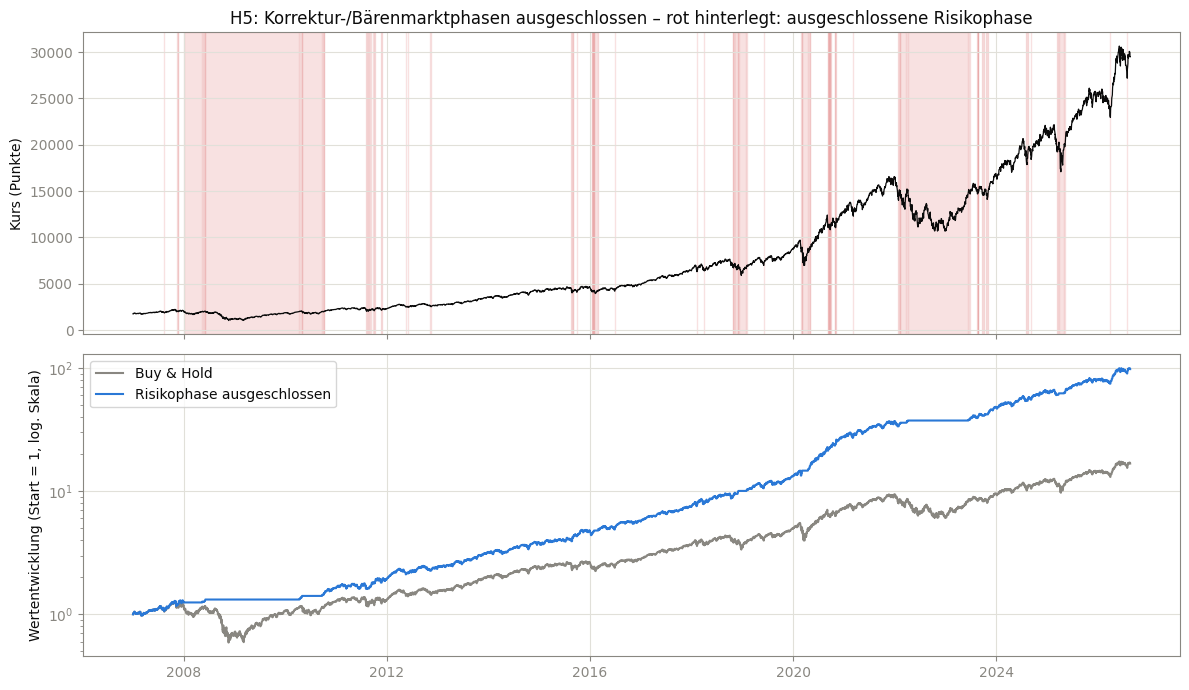

Anteil ausgeschlossener Handelstage: 26.0%
Gesamtrendite  - Buy & Hold: 1576.7% | Ausschluss: 9701.5%
CAGR           - Buy & Hold: 15.4% | Ausschluss: 26.3%
Max Drawdown   - Buy & Hold: -53.7% | Ausschluss: -9.9%


In [55]:
_ = plotte_was_wäre_wenn("H5_Drawdown", regime_definitionen["H5_Drawdown"], "H5: Korrektur-/Bärenmarktphasen ausgeschlossen")


**Ergebnis:** Der Ausschluss der 26,0 % Handelstage in Korrektur- oder Bärenmarktphasen (mindestens 10 % unter dem bisherigen Hoch) senkt den Max Drawdown von −53,7 % auf −9,9 % und erhöht die CAGR von 15,5 % auf 26,4 % – die stärkste CAGR aller nicht auf SMA20 basierenden Parametrisierungen.

**Praxisrelevanz für Börseninvestoren:** H5 benötigt keine SMA-Parameterwahl und ist damit die am einfachsten kommunizierbare Risikokennzahl der gesamten Analyse; das Ergebnis bestätigt, dass diese parameterfreie Kennzahl eine mindestens ebenso wirksame Risikosteuerung ermöglicht wie die SMA-basierten Signale – im Einklang mit dem in Abschnitt 4.7 dokumentierten Befund, dass H5 auch bei der reinen Signifikanzprüfung die robusteste Einzelhypothese ist.

#### H6 – Überverkaufte Phasen (RSI < 30) ausgeschlossen


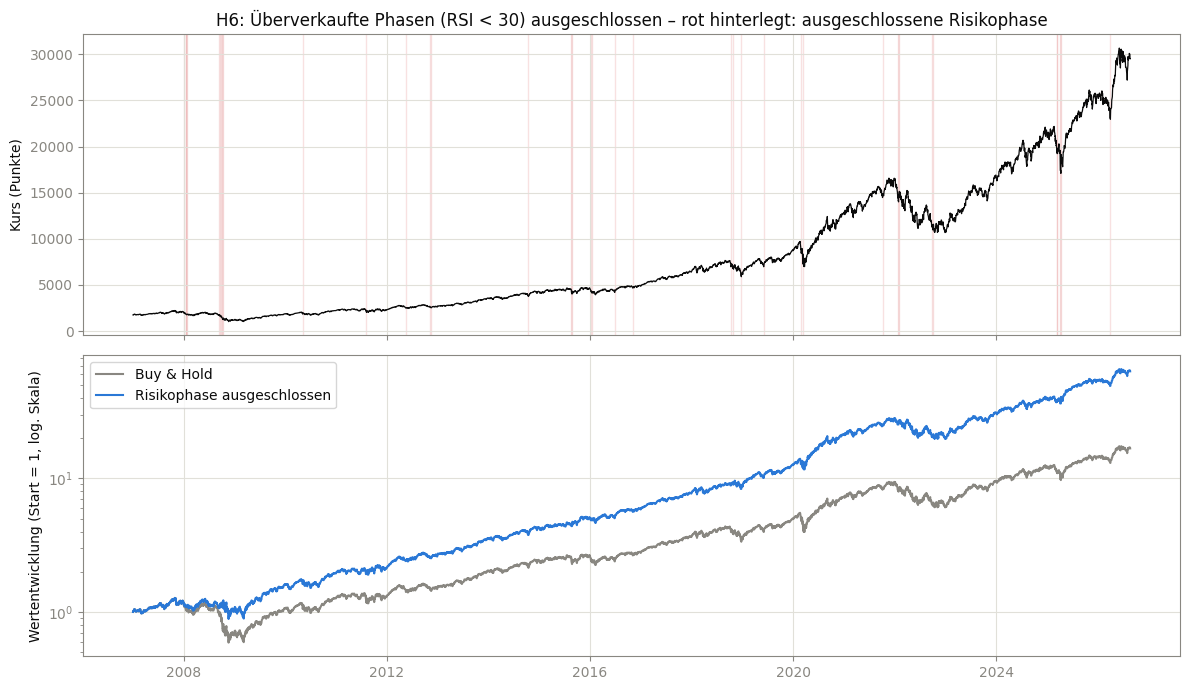

Anteil ausgeschlossener Handelstage: 1.1%
Gesamtrendite  - Buy & Hold: 1576.7% | Ausschluss: 6232.9%
CAGR           - Buy & Hold: 15.4% | Ausschluss: 23.5%
Max Drawdown   - Buy & Hold: -53.7% | Ausschluss: -30.4%


In [56]:
_ = plotte_was_wäre_wenn("H6_RSI_überverkauft", regime_definitionen["H6_RSI_überverkauft"], "H6: Überverkaufte Phasen (RSI < 30) ausgeschlossen")


**Ergebnis:** Obwohl RSI < 30 nur an 1,1 % der Handelstage auftritt, senkt der Ausschluss dieser Tage den Max Drawdown bereits deutlich von −53,7 % auf −30,4 % und erhöht die CAGR von 15,5 % auf 23,6 %.

**Praxisrelevanz für Börseninvestoren:** Dieses Ergebnis unterstreicht den in Abschnitt 4.6 dokumentierten, kontraintuitiven Befund: Extreme Überverkauft-Phasen konzentrieren sich zeitlich eng auf die volatilsten Marktphasen. Wegen der geringen Anzahl betroffener Tage ist RSI < 30 kein praktikables alleiniges Steuerungssignal, kann aber – wie in Abschnitt 6.5 beschrieben – als punktueller Verschärfungshinweis innerhalb einer Gelb-Phase dienen.

#### Kombinierte Ampel – Rot-Phasen ausgeschlossen


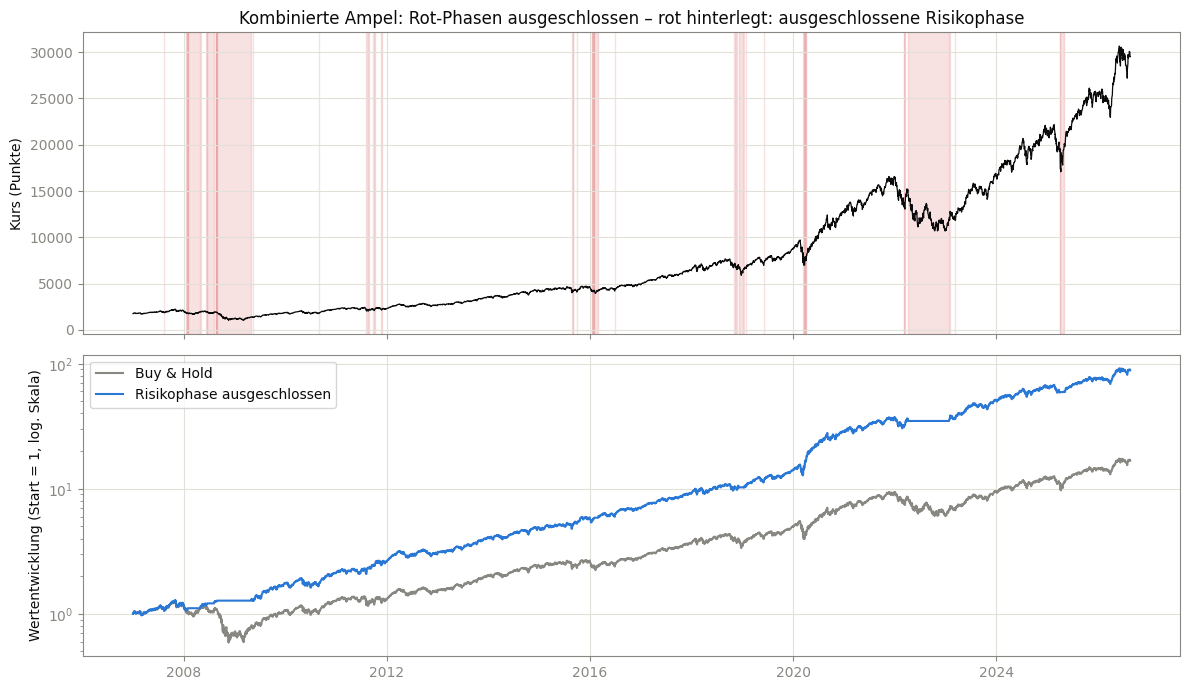

Anteil ausgeschlossener Handelstage: 12.2%
Gesamtrendite  - Buy & Hold: 1576.7% | Ausschluss: 8745.4%
CAGR           - Buy & Hold: 15.4% | Ausschluss: 25.7%
Max Drawdown   - Buy & Hold: -53.7% | Ausschluss: -18.5%


In [57]:
_ = plotte_was_wäre_wenn("Ampel_Rot", regime_definitionen["Ampel_Rot"], "Kombinierte Ampel: Rot-Phasen ausgeschlossen")


**Ergebnis:** Der Ausschluss der 12,2 % Rot-Handelstage senkt den Max Drawdown von −53,7 % auf −18,5 % und erhöht die CAGR von 15,5 % auf 25,8 %.

**Praxisrelevanz für Börseninvestoren:** Die kombinierte Ampel schließt mit 12,2 % deutlich weniger Handelstage aus als die Einzelbausteine H1, H2 und H5 (jeweils rund 21–35 %), erzielt aber eine CAGR-Verbesserung, die im oberen Bereich der Einzelbausteine liegt (übertroffen nur von H5 und den SMA20-basierten Signalen) bei einem Max Drawdown auf Höhe von H2/SMA200. Die Kombination reduziert damit die Zahl der als riskant markierten Tage gegenüber den Einzelsignalen spürbar, ohne deren Risikoreduktion wesentlich zu verwässern – ein Beleg dafür, dass die in Abschnitt 6.3 definierte Übereinstimmungsregel einen sinnvollen Kompromiss zwischen Selektivität und Schutzwirkung darstellt.

### 7.5 Zusammenfassende Einordnung

Über alle betrachteten Hypothesen hinweg bestätigt die Was-wäre-wenn-Analyse den in den Abschnitten 4.7 und 6.4 dokumentierten Kernbefund aus einer weiteren, praxisnahen Perspektive: Regelbasierte Ausschlussstrategien auf Basis von H1, H2, H5, H6 und der kombinierten Ampel hätten den historischen Max Drawdown des NASDAQ 100 durchgängig deutlich reduziert, bei gleichzeitig höherer annualisierter Rendite – bei der kombinierten Ampel etwa von −53,7 % auf −18,5 % bei einer CAGR-Steigerung von 15,5 % auf 25,8 %. Die einzige Ausnahme bilden die beiden Cross-Over-Paare (H3), die zwar ebenfalls den Max Drawdown senken, dabei aber – im Einklang mit ihrer bereits in Abschnitt 4.3 dokumentierten fehlenden statistischen Absicherung – die Rendite gegenüber Buy & Hold sogar schmälern. Die kombinierte Ampel liefert dabei mit einem vergleichsweise geringen Anteil ausgeschlossener Handelstage (12,2 %) ein ausgewogenes Ergebnis und bestätigt damit die in Abschnitt 6 hergeleitete Kategorienregel auch aus Rendite-/Risikosicht. Sämtliche Werte basieren auf einer vereinfachten Simulation ohne Transaktionskosten und Cash-Verzinsung (siehe methodische Abgrenzung zu Beginn dieses Abschnitts) und sind entsprechend als oberes Potenzial, nicht als realistisch erzielbare Rendite zu verstehen – dies gilt in besonderem Maße für die rechnerisch extremen CAGR-Werte der SMA20-basierten Parametrisierungen (H1/H2), deren praktische Umsetzbarkeit durch häufige Signalwechsel stark eingeschränkt wäre.

## 8. Export der Ergebnisse

Sämtliche Ergebnistabellen werden als Einzel-CSV-Dateien sowie als
gemeinsame Excel-Arbeitsmappe (ein Tabellenblatt je Hypothese sowie die
Robustheitsübersicht) im Ordner `Hypothesenanalysen/` gespeichert.


In [58]:
INDEX_DATEINAME = INDEX_NAME.replace(" ", "_").replace("&", "and")

xlsx_pfad = EXPORT_DIR / f"{INDEX_DATEINAME}_hypothesenanalysen.xlsx"
with pd.ExcelWriter(xlsx_pfad, engine="openpyxl") as writer:
    for name, tabelle in alle_ergebnisse.items():
        tabelle.to_excel(writer, sheet_name=name[:31], index=False)
    tabelle_robustheit.to_excel(writer, sheet_name="Robustheit_Übersicht", index=False)
    # Ampel-Kategoriendefinition (Abschnitt 6) und Was-wäre-wenn-Kennzahlen
    # (Abschnitt 7) ergänzen die Hypothesentabellen um die abgeleitete
    # Anwendungssicht des Notebooks.
    tabelle_ampel.to_excel(writer, sheet_name="Ampel_Validierung", index=False)
    tabelle_was_wäre_wenn.to_excel(writer, sheet_name="Was_wäre_wenn", index=False)

csv_dateien = []
for name, tabelle in alle_ergebnisse.items():
    csv_pfad = EXPORT_DIR / f"{INDEX_DATEINAME}_{name}.csv"
    tabelle.to_csv(csv_pfad, index=False)
    csv_dateien.append(csv_pfad.name)

robustheit_csv = EXPORT_DIR / f"{INDEX_DATEINAME}_Robustheit_Übersicht.csv"
tabelle_robustheit.to_csv(robustheit_csv, index=False)
csv_dateien.append(robustheit_csv.name)

ampel_csv = EXPORT_DIR / f"{INDEX_DATEINAME}_Ampel_Validierung.csv"
tabelle_ampel.to_csv(ampel_csv, index=False)
csv_dateien.append(ampel_csv.name)

was_wäre_wenn_csv = EXPORT_DIR / f"{INDEX_DATEINAME}_Was_wäre_wenn.csv"
tabelle_was_wäre_wenn.to_csv(was_wäre_wenn_csv, index=False)
csv_dateien.append(was_wäre_wenn_csv.name)

print(f"Excel-Arbeitsmappe gespeichert: {xlsx_pfad}")
print("Einzel-CSV-Dateien gespeichert:")
for f in csv_dateien:
    print(" -", f)


Excel-Arbeitsmappe gespeichert: Hypothesenanalysen\NASDAQ_100_hypothesenanalysen.xlsx
Einzel-CSV-Dateien gespeichert:
 - NASDAQ_100_H1_Kurs_vs_SMA.csv
 - NASDAQ_100_H2_SMA_Richtung.csv
 - NASDAQ_100_H3_CrossOver.csv
 - NASDAQ_100_H4_Divergenz.csv
 - NASDAQ_100_H5_Drawdown_vom_Hoch.csv
 - NASDAQ_100_H6_Momentum_RSI.csv
 - NASDAQ_100_Robustheit_Übersicht.csv
 - NASDAQ_100_Ampel_Validierung.csv
 - NASDAQ_100_Was_wäre_wenn.csv


## 9. Zusammenfassung

Diese Analyse hat sechs Hypothesen zur Aussagekraft SMA-basierter und verwandter technischer Indikatoren für den NASDAQ 100 im Zeitraum 2007 bis 2026 systematisch geprüft, für sämtliche untersuchten Parametrisierungen grafisch ausgewertet und hinsichtlich ihrer Eignung für ein Ampelsystem bewertet.

**Kernergebnis:** Die robustesten Bausteine sind die Trendposition und -richtung des Kurses relativ zum SMA200 (H1, H2) sowie der Abstand vom bisherigen Höchststand (H5) – Letzterer sticht hervor, da bei ihm sowohl das Risiko- als auch das Renditesignal in allen drei Horizonten durchgängig statistisch signifikant ist. Bei H1 und H2 ist das Risikosignal deutlich robuster abgesichert als das Renditesignal; bei kurzen und mittleren Zeitfenstern zeigt sich sogar ein signifikant gegenläufiges Renditeverhalten (Mean-Reversion). Cross-Over-Signale (H3) liefern in keinem der zwei testbaren Paare ein signifikantes Ergebnis. Divergenzsignale (H4) sind bereits auf der kürzesten geprüften Zeitebene nicht statistisch testbar (9 bzw. 2 Ereignisse seit 2007, beide unterhalb der Mindeststichprobe). Der RSI (H6) zeigt entgegen der klassischen Lehrmeinung keinen Umkehreffekt, sondern in der Mehrheit der Horizonte einen konsistenten Risiko-Rendite-Zusammenhang mit erhöhtem Risiko bei überverkauften Ständen.

**Schlussfolgerung für das Ampelsystem:** Ein trendbasiertes Ampelsystem für den NASDAQ 100 sollte primär als Risikoindikator ausgelegt werden, mit H1/H2 (SMA200) und H5 als Kernbausteinen. Die statistische Validierung der resultierenden drei Ampelfarben (Abschnitt 6.4) bestätigt eine überwiegend signifikante Risikotrennung; bei der Rendite zeigt sich dagegen ein nicht-monotones Muster, bei dem die Gelb-Phase historisch die höchste erwartete Rendite aufwies – ein Befund, der bei der Kommunikation der Ampel an Investoren berücksichtigt werden sollte. Die vorliegenden Ergebnistabellen (Abschnitt 6) bilden die quantitative Grundlage für die Kalibrierung entsprechender Schwellenwerte.

**Ampel-Systematik und Was-wäre-wenn-Analyse:** Abschnitt 6 leitet aus H1, H2 und H5 eine dreistufige Ampel-Kategorisierung (Grün/Gelb/Rot) ab, deren Risikotrennung in sieben von neun Farbpaar-Horizont-Kombinationen statistisch signifikant ist (Abschnitt 6.4). Die Was-wäre-wenn-Analyse in Abschnitt 7 zeigt, dass ein Ausschluss der jeweils ungünstigeren Regimephase den historischen Max Drawdown des NASDAQ 100 in nahezu allen betrachteten Parametrisierungen deutlich reduziert hätte – bei der kombinierten Ampel von −53,7 % auf −18,5 %, bei gleichzeitig höherer annualisierter Rendite (25,8 % statt 15,5 %). Diese Ergebnisse beruhen auf einer vereinfachten Simulation ohne Transaktionskosten und sind als Beleg für das grundsätzliche Potenzial, nicht als realistisch handelbare Strategie zu verstehen.